**Install and import required Libraries**

In [1]:
!pip install surprise
!pip install "numpy<2.0"

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Data sets**

In [3]:
# load listings data
listings_df = pd.read_csv('listings (1).csv.gz', compression='gzip')
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44077,https://www.airbnb.com/rooms/44077,20250613040039,2025-06-13,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,...,4.93,4.68,4.82,NaN,f,2,0,2,0,2.19
1,85156,https://www.airbnb.com/rooms/85156,20250613040039,2025-06-13,city scrape,Cosy Comfortable Irish Cottage 1 Double Bed,Our Cottage is a charming light filled cottage...,"I love Dundrum and its surrounding areas ,<br ...",https://a0.muscache.com/pictures/1749253/9ed2a...,193005,...,4.89,4.64,4.78,NaN,f,2,0,2,0,2.00
2,159889,https://www.airbnb.com/rooms/159889,20250613040039,2025-06-13,city scrape,Friendly Single Room,Washing can be done at a cost of €5 per load....,Plenty of buses into the city and the area is ...,https://a0.muscache.com/pictures/3031697/a8259...,766611,...,4.87,4.65,4.71,NaN,f,3,0,3,0,2.79
3,162809,https://www.airbnb.com/rooms/162809,20250613040039,2025-06-13,previous scrape,5.5 miles south of Dublin City :^),A nice place to relax after the bustle of the ...,"Close to the sea, hill walks and the city - vi...",https://a0.muscache.com/pictures/86694529/c07b...,777681,...,4.97,4.78,4.85,NaN,f,2,0,2,0,3.22
4,165828,https://www.airbnb.com/rooms/165828,20250613040039,2025-06-13,city scrape,Pádraig Pearse apt. Kilmainham,"Don't just visit Dublin, experience Dublin in ...","Enjoy a walk along the grand canal, or just ob...",https://a0.muscache.com/pictures/34311419/b3f6...,790601,...,4.77,4.40,4.56,NaN,f,4,4,0,0,0.51


In [4]:
listings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6781 entries, 0 to 6780
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6781 non-null   int64  
 1   listing_url                                   6781 non-null   object 
 2   scrape_id                                     6781 non-null   int64  
 3   last_scraped                                  6781 non-null   object 
 4   source                                        6781 non-null   object 
 5   name                                          6781 non-null   object 
 6   description                                   6640 non-null   object 
 7   neighborhood_overview                         2457 non-null   object 
 8   picture_url                                   6781 non-null   object 
 9   host_id                                       6781 non-null   i

In [5]:
# load reviews data
reviews_df = pd.read_csv('reviews.csv.gz', compression='gzip')
reviews_df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,44077,203703,2011-03-20,393348,Christian,We enjoyed our stay very much. The room was co...
1,44077,211369,2011-03-28,444004,Solidea,We have been here 4 nights. Stay in a home is ...
2,44077,234215,2011-04-21,465058,Michael And Isabelle,Teresa and Hughie were great hosts. They were ...
3,44077,261843,2011-05-13,490005,Weston,"No surprises, was as described. Very gracious..."
4,44077,268148,2011-05-17,520460,Barbara,"Teresa was a lovely hostess, and we had a deli..."


In [6]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310128 entries, 0 to 310127
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     310128 non-null  int64 
 1   id             310128 non-null  int64 
 2   date           310128 non-null  object
 3   reviewer_id    310128 non-null  int64 
 4   reviewer_name  310128 non-null  object
 5   comments       310100 non-null  object
dtypes: int64(3), object(3)
memory usage: 14.2+ MB


**Data Pre-Processing**

In [7]:
reviews_df.isna().sum()

,0
listing_id,0
id,0
date,0
reviewer_id,0
reviewer_name,0
comments,28


In [8]:
reviews_df.dropna(inplace=True)

In [9]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310100 entries, 0 to 310127
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     310100 non-null  int64 
 1   id             310100 non-null  int64 
 2   date           310100 non-null  object
 3   reviewer_id    310100 non-null  int64 
 4   reviewer_name  310100 non-null  object
 5   comments       310100 non-null  object
dtypes: int64(3), object(3)
memory usage: 16.6+ MB


Merge both data set into a single DataFrame using a common identifier, where the id column from the listing’s dataset was matched with the listing_id column from the review’s dataset

In [10]:
dublin_merged_df = pd.merge(listings_df, reviews_df, left_on='id', right_on='listing_id')
dublin_merged_df.head(1)

,id_x,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,id_y,date,reviewer_id,reviewer_name,comments
0,44077,https://www.airbnb.com/rooms/44077,20250613040039,2025-06-13,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,...,0,2,0,2.19,44077,203703,2011-03-20,393348,Christian,We enjoyed our stay very much. The room was co...


In [11]:
dublin_merged_df.duplicated().sum()

0

In [12]:

dublin_merged_df.isna().sum()

,0
id_x,0
listing_url,0
scrape_id,0
last_scraped,0
source,0
...,...
id_y,0
date,0
reviewer_id,0
reviewer_name,0


In [13]:
dublin_merged_df['neighbourhood_cleansed'].nunique()

4

In [14]:
dublin_merged_df['neighbourhood'].nunique()

262

In [15]:
dublin_merged_df['property_type'].nunique()

51

In [16]:
dublin_merged_df['room_type'].nunique()

4

In [17]:
columns_to_drop = [
    'scrape_id', 'last_scraped', 'name',
    'neighborhood_overview', 'host_url',
    'host_name', 'host_location', 'host_about', 'host_thumbnail_url',
    'host_picture_url', 'host_neighbourhood', 'host_verifications',
    'neighbourhood_group_cleansed', 'host_total_listings_count', 'property_type',
    'minimum_minimum_nights', 'maximum_minimum_nights', 'bathrooms_text', 'minimum_maximum_nights',
    'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'calendar_updated', 'neighbourhood', 'calendar_last_scraped', 'number_of_reviews_ltm', 'license', 'has_availability',
    'host_id', 'source', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms'
]

# Drop the specified columns
dublin_merged_df = dublin_merged_df.drop(columns=columns_to_drop)

Several variables were removed prior to modelling to improve data quality and reduce dimensionality. These included unique identifiers and URLs (e.g., scrape_id, host_id, listing_url), which do not contain predictive information; redundant or higher-level location descriptors (e.g., neighbourhood, neighbourhood_group_cleansed), which duplicate spatial effects already captured by geographic coordinates; and long free-text fields (e.g., host_about, neighborhood_overview), which would require separate natural language processing pipelines. Additionally, technical calendar fields and derived booking constraint variables (e.g., minimum_nights_avg_ntm, calendar_updated) were excluded as they describe data collection processes rather than intrinsic listing characteristics. Finally, calculated host listing count variables were dropped because they replicate information already captured by host_listings_count, leading to multicollinearity without adding independent explanatory value.

In [18]:
# check remaining columns
dublin_merged_df.columns

Index(['id_x', 'listing_url', 'description', 'picture_url', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'reviews_per_month',
       'listing_id', '

In [19]:
# data type check
dublin_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310100 entries, 0 to 310099
Data columns (total 51 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_x                         310100 non-null  int64  
 1   listing_url                  310100 non-null  object 
 2   description                  305872 non-null  object 
 3   picture_url                  310100 non-null  object 
 4   host_since                   309837 non-null  object 
 5   host_response_time           291204 non-null  object 
 6   host_response_rate           291204 non-null  object 
 7   host_acceptance_rate         303964 non-null  object 
 8   host_is_superhost            300605 non-null  object 
 9   host_listings_count          309837 non-null  float64
 10  host_has_profile_pic         309837 non-null  object 
 11  host_identity_verified       309837 non-null  object 
 12  neighbourhood_cleansed       310100 non-null  object 
 13 

In [20]:
dublin_merged_df.isna().sum()

,0
id_x,0
listing_url,0
description,4228
picture_url,0
host_since,263
host_response_time,18896
host_response_rate,18896
host_acceptance_rate,6136
host_is_superhost,9495
host_listings_count,263


Remove rows with missing values in our target variable. This is because imputating the target variable would create artificial data, introduce bias and can also lead to data leakage.

In [21]:
dublin_merged_df.dropna(subset=['price'], inplace=True)

In [22]:

dublin_merged_df.isna().sum()

,0
id_x,0
listing_url,0
description,3783
picture_url,0
host_since,263
host_response_time,8680
host_response_rate,8680
host_acceptance_rate,3820
host_is_superhost,8101
host_listings_count,263


Missing values were treated based on their semantic meaning and distribution. Remove rows with missing values in the target variable. This is because imputating the target variable would
create artificial data, introduce bias and can also lead to data leakage.
Structural listing attributes (bathrooms, bedrooms, and beds) had minimal missingness and were imputed using the median to preserve robustness against skewness. Host-related categorical features with high missingness were imputed with an "Unknown" category to avoid introducing false information. Host response and acceptance rates were converted to numeric format and imputed using the median, alongside missingness indicator variables to retain potential information encoded in missing values. Text fields such as listing descriptions were replaced with empty strings. No rows were removed to avoid systematic bias and loss of information.

In [23]:
# TEXT FIELDS
dublin_merged_df['description'] = dublin_merged_df['description'].fillna("")


# HOST RESPONSE COLUMNS
rate_cols = ['host_response_rate', 'host_acceptance_rate']

for col in rate_cols:
    # Remove % and convert to numeric
    dublin_merged_df[col] = dublin_merged_df[col].str.replace('%', '', regex=False)
    dublin_merged_df[col] = pd.to_numeric(dublin_merged_df[col], errors='coerce')

    # Impute with median
    dublin_merged_df[col] = dublin_merged_df[col].fillna(dublin_merged_df[col].median())


# HOST RESPONSE TIME
dublin_merged_df['host_response_time'] = dublin_merged_df['host_response_time'].fillna("Unknown")

# HOST SUPERHOST STATUS
dublin_merged_df['host_is_superhost'] = dublin_merged_df['host_is_superhost'].fillna("Unknown")

# HOST PROFILE INFO
dublin_merged_df['host_has_profile_pic'] = dublin_merged_df['host_has_profile_pic'].fillna("Unknown")
dublin_merged_df['host_identity_verified'] = dublin_merged_df['host_identity_verified'].fillna("Unknown")

# Convert host_since to datetime and impute
dublin_merged_df['host_since'] = pd.to_datetime(dublin_merged_df['host_since'], errors='coerce')
dublin_merged_df['host_since'] = dublin_merged_df['host_since'].fillna(dublin_merged_df['host_since'].median())

# Host listings count
dublin_merged_df['host_listings_count'] = dublin_merged_df['host_listings_count'].fillna(dublin_merged_df['host_listings_count'].median())

# STRUCTURAL NUMERIC FEATURES
num_cols = ['bathrooms', 'bedrooms', 'beds']

for col in num_cols:
    dublin_merged_df[col] = dublin_merged_df[col].fillna(dublin_merged_df[col].median())

# FINAL CHECK
print(dublin_merged_df.isna().sum().sort_values(ascending=False))


id_x                           0
review_scores_cleanliness      0
number_of_reviews              0
number_of_reviews_l30d         0
availability_eoy               0
number_of_reviews_ly           0
estimated_occupancy_l365d      0
estimated_revenue_l365d        0
first_review                   0
last_review                    0
review_scores_rating           0
review_scores_accuracy         0
review_scores_checkin          0
availability_90                0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
instant_bookable               0
reviews_per_month              0
listing_id                     0
id_y                           0
date                           0
reviewer_id                    0
reviewer_name                  0
availability_365               0
availability_60                0
listing_url                    0
neighbourhood_cleansed         0
description                    0
picture_url                    0
host_since

In [24]:
# dublin_merged_df.dropna(inplace=True)

In [25]:
#check null
dublin_merged_df.isna().sum().sum()

0

In [26]:
# Remove currency symbols and commas from the 'price' column, then convert to float
dublin_merged_df['price'] = dublin_merged_df['price'].replace('[$,]', '', regex=True).astype(float)



Convert Date to datetime format for data integrity and enabling accurate analysis.

In [27]:
# Convert 'date' to datetime format
dublin_merged_df['date'] = pd.to_datetime(dublin_merged_df['date'])

# Convert host_since to datetime
dublin_merged_df['host_since'] = pd.to_datetime(dublin_merged_df['host_since'], errors='coerce')

# Convert host_since to datetime first_review and last_review
dublin_merged_df['first_review'] = pd.to_datetime(dublin_merged_df['first_review'])
dublin_merged_df['last_review'] = pd.to_datetime(dublin_merged_df['last_review'])

In [28]:
print(f"Of the Airbnb hosts that are still listing on the site, the first joined on {min(dublin_merged_df.host_since).strftime('%d %B %Y')}, and the most recent joined on {max(dublin_merged_df.host_since).strftime('%d %B %Y')}.")

Of the Airbnb hosts that are still listing on the site, the first joined on 25 November 2009, and the most recent joined on 03 June 2025.


In [29]:
numeric_cols = dublin_merged_df.select_dtypes(include=['number']).columns
len(numeric_cols)

34

In [30]:
categorical_cols = dublin_merged_df.select_dtypes(include=['object']).columns
len(categorical_cols)

13

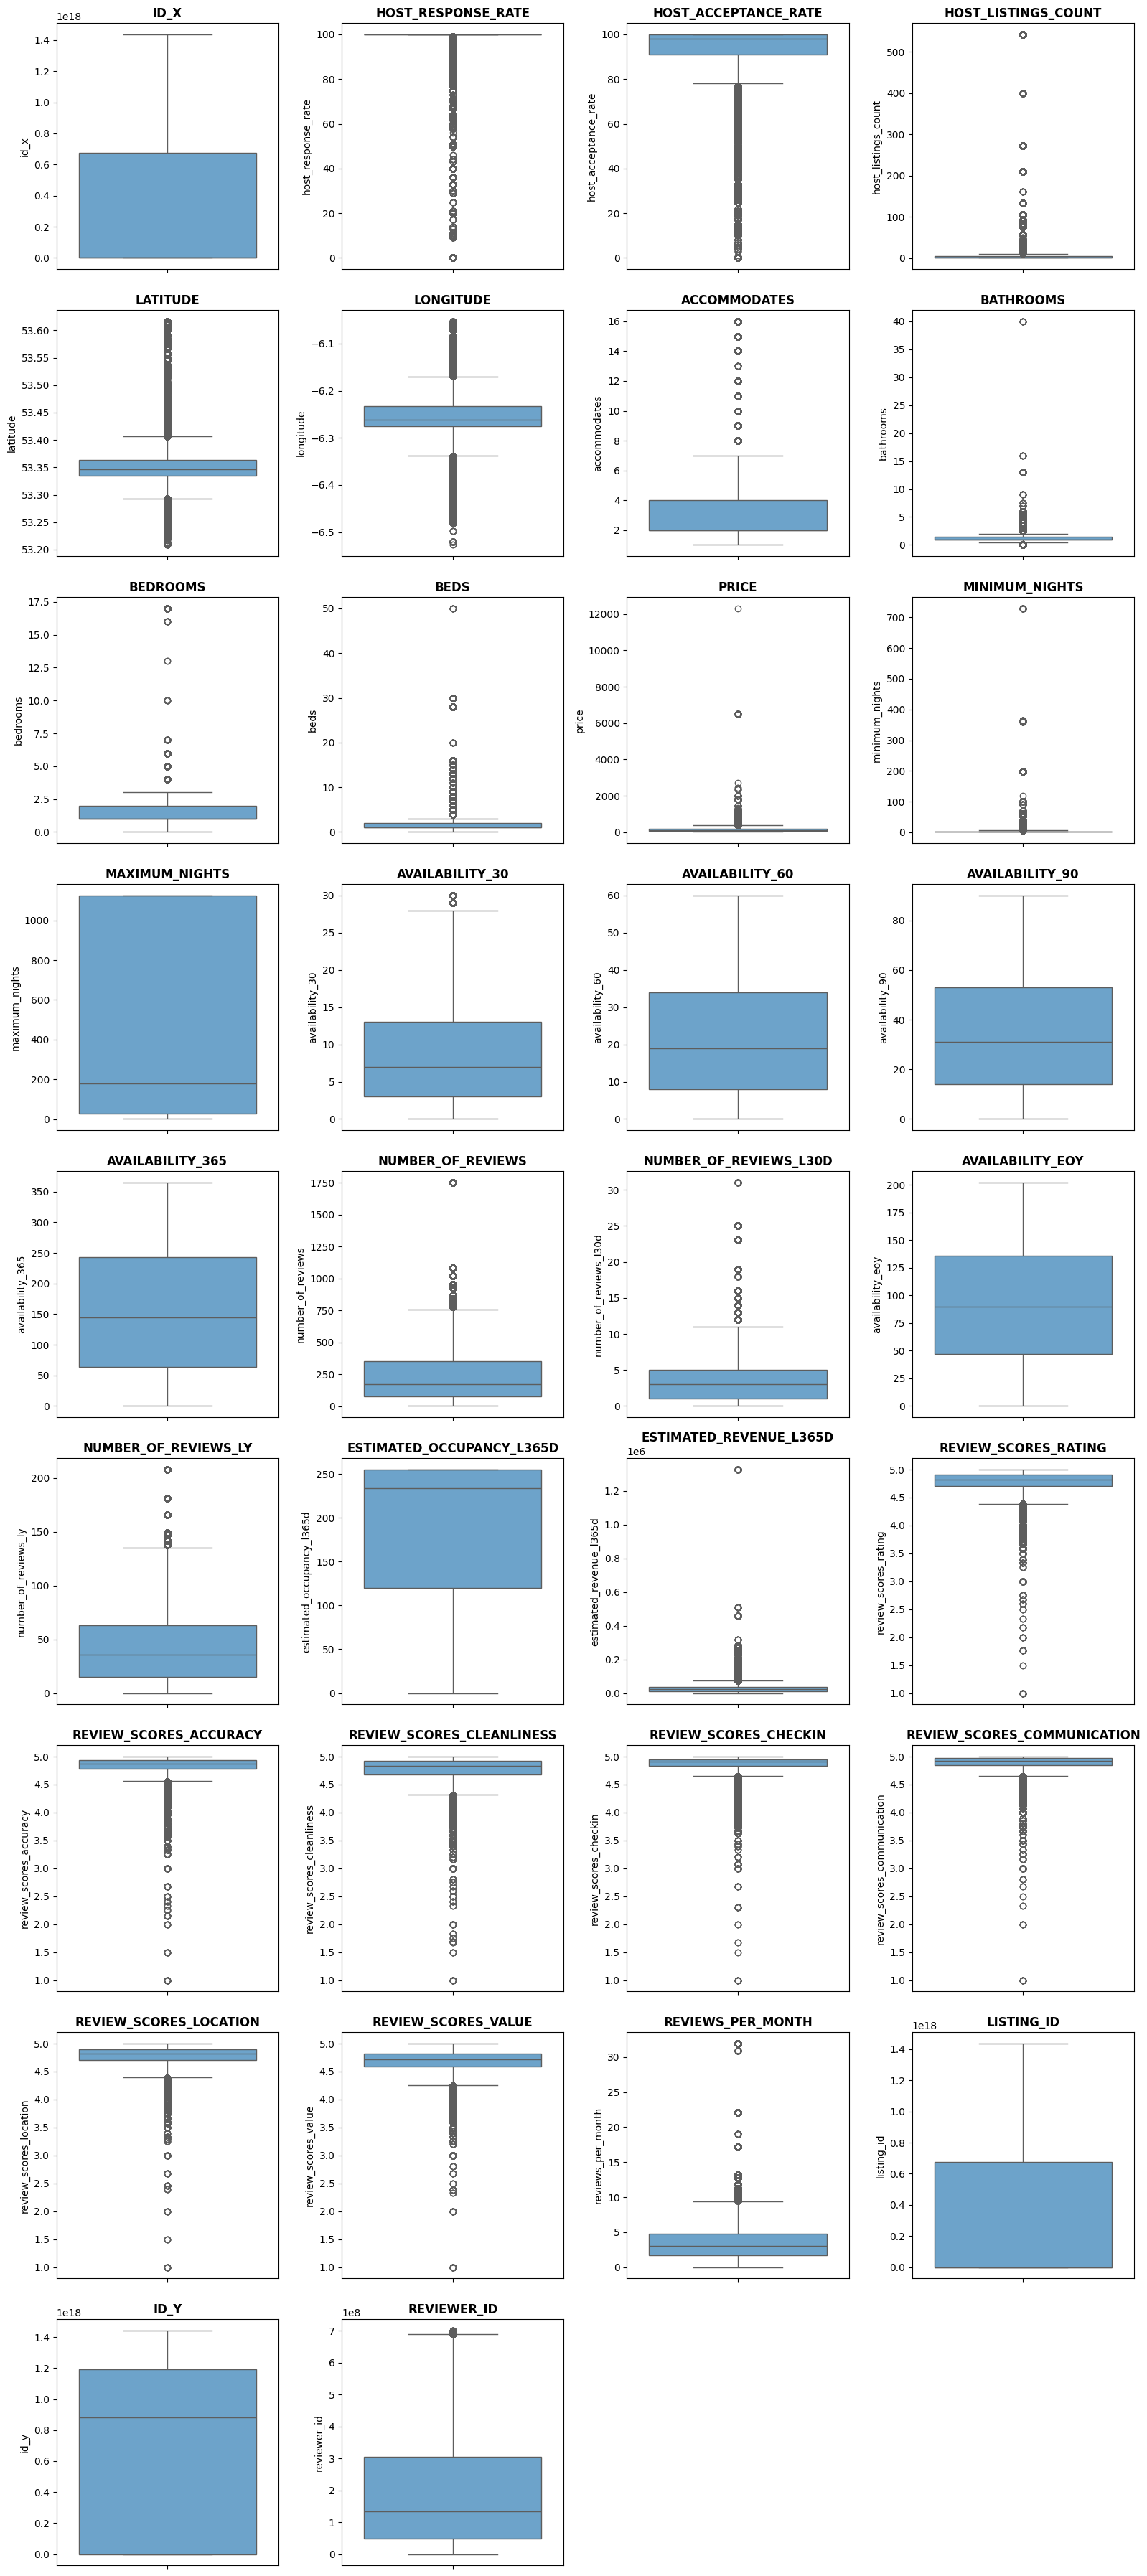

In [31]:
import math

# Calculate rows needed for a 4-column wide grid
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows)) # Adjust height based on rows

for i, col in enumerate(numeric_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=dublin_merged_df[col], color="#5da5da")
    plt.title(col.upper(), fontweight='bold')

plt.tight_layout()
plt.show()


Price Distribution

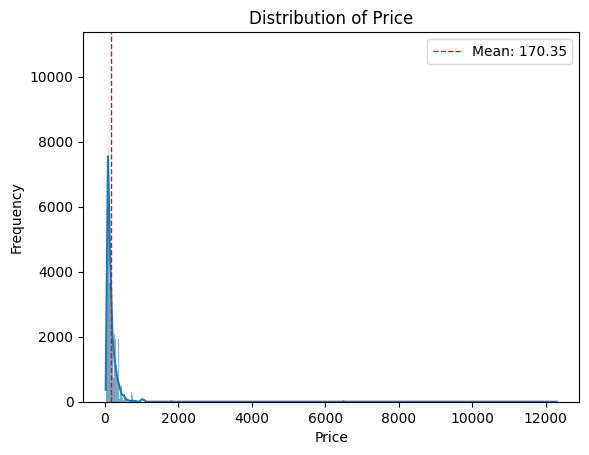

In [32]:
# mean of the 'price' column
mean_value = dublin_merged_df['price'].mean()

# histogram
sns.histplot(dublin_merged_df['price'], kde=True)

# Add a vertical line at the mean
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_value:.2f}')

# Add legend and labels
plt.legend()
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')

plt.show();

In [33]:
from IPython.display import Image, HTML

# 1. Get unique listings, sorted by price (assuming 'price' is the column name)
top_listings = dublin_merged_df.drop_duplicates('listing_id').sort_values(by='price', ascending=False).head(5)

# 2. Function to convert URL to HTML image tag
def path_to_image_html(path):
    return f'<img src="{path}" width="200" >'

# 3. Select columns and display with rendered images
# Update 'price' if your column is named differently (e.g., 'price_x')
display_cols = ['price', 'picture_url', 'listing_url', 'description']
output = top_listings[display_cols]

# Render the table with images
HTML(output.to_html(escape=False, formatters=dict(picture_url=path_to_image_html)))



,price,picture_url,listing_url,description
257942,12299.0,,https://www.airbnb.com/rooms/878138901203624105,"GREAT APARTMENT CLOSE TO EVERYTHING RIGHT IN THE CITY CENTRE! near to OCONNELL STREET. WE HAVE A DOUBLE BED IN EACH OF THE TWO BEDROOMS AND A LARGE DOUBLE SOFABED IN THE LIVINGROOM - YOUR GROUP/FAMILY WILL BENEFIT FROM EVERYTHING THIS APARTMENT HAS TO OFFER There are a host of shops, restaurants, cafés and bars closeby. WE HAVE A fully equipped kitchen FOR COOKING, TV and reliable FAST WIFI and a desk/dining table FOR 6"
278489,6499.0,,https://www.airbnb.com/rooms/1014486078433786334,"This fine accommodation comprises of living / dining room, kitchen, two double bedrooms and family bathroom. You will be close to everything when you stay at this centrally-located place.The central walkway that overlooks the Royal Canal provides easy access to Luas stop and the Docklands train station. Connolly Train/Dart Station and the city centre are within a five and ten minute walk away. The shops and restaurants are on your doorstep"
235680,2700.0,,https://www.airbnb.com/rooms/707847129885560331,"2 bedroom apartment with everything you need, Short walk to city centre,Fast wifi, Sleep 4 people comfortably in double bed, Sleep 5th and 6th guest in sofa bed that flips into a double bed,I provide instant coffee and a selection of tea. Some breakfast cereal if your lucky (buy your own milk),Excellent bus service from the airport with bus stop outside front door of apartment,Great pubs and restaurants within 2 minute walk of the apartment"
306172,2430.0,,https://www.airbnb.com/rooms/1318215232633591694,"Welcome to our charming 1-bedroom apartment located at Parnell Place, D1. This cozy space is perfect for accommodating up to 6 people, offering a comfortable double bed and 2convenient sofa beds.Our apartment is situated in a prime location. You'll find yourself within easy reach of the city's vibrant attractions, bustling restaurants, and lively entertainment options. Whether you're exploring historic landmarks or indulging in shopping sprees, you'll have everything at your doorstep."
288236,2370.0,,https://www.airbnb.com/rooms/1106321979343477192,"Welcome to our charming 1-bedroom apartment nestled on Parnell Place, D1. This cozy retreat comfortably accommodates up to 4 guests, offering a plush double bed and a convenient sofa bed.Our apartment enjoys a prime location, providing easy access to the city's vibrant attractions, bustling restaurants, and lively entertainment options. Whether you're exploring historic landmarks or enjoying shopping sprees, everything you need is right at your doorstep."


In [34]:
dublin_merged_df['price'].describe()

,price
count,276126.000000
mean,170.346679
std,171.936673
min,20.000000
25%,81.000000
50%,125.000000
75%,206.000000
max,12299.000000


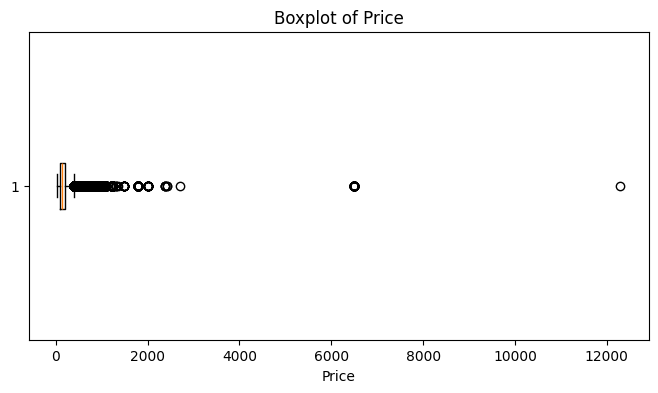

In [35]:
plt.figure(figsize=(8, 4))
plt.boxplot(dublin_merged_df['price'], vert=False)
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

**Remove Outliers from Price Using Winsorization Method**

Nightly prices exhibited a highly

right-skewed distribution with extreme values. Capped the top 1% of the most expensive prices in the dataset Rather than removing high-priced listings, which may represent legitimate luxury properties, prices were winsorised at the upper percentile and log-transformed. This approach preserved all observations while reducing the influence of extreme values and improving model stability.

In [36]:
# Compute 99th percentile cap
upper_cap = dublin_merged_df['price'].quantile(0.99)
print(f"99th percentile cap: {upper_cap}")

# Winsorise (cap extreme values)
dublin_merged_df['price'] = dublin_merged_df['price'].clip(upper=upper_cap)

# Log-transform for modelling
# dublin_merged_df['log_price'] = np.log1p(dublin_merged_df['price'])

# Check new distribution
# print(dublin_merged_df['price_capped'].describe())
# print(dublin_merged_df['log_price'].describe())

99th percentile cap: 817.0


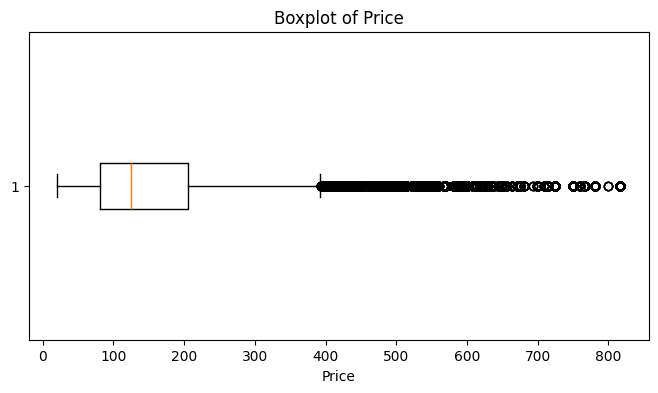

In [37]:
plt.figure(figsize=(8, 4))
plt.boxplot(dublin_merged_df['price'], vert=False)
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

In [38]:
dublin_merged_df['price'].describe()

,price
count,276126.000000
mean,167.014588
std,129.972853
min,20.000000
25%,81.000000
50%,125.000000
75%,206.000000
max,817.000000


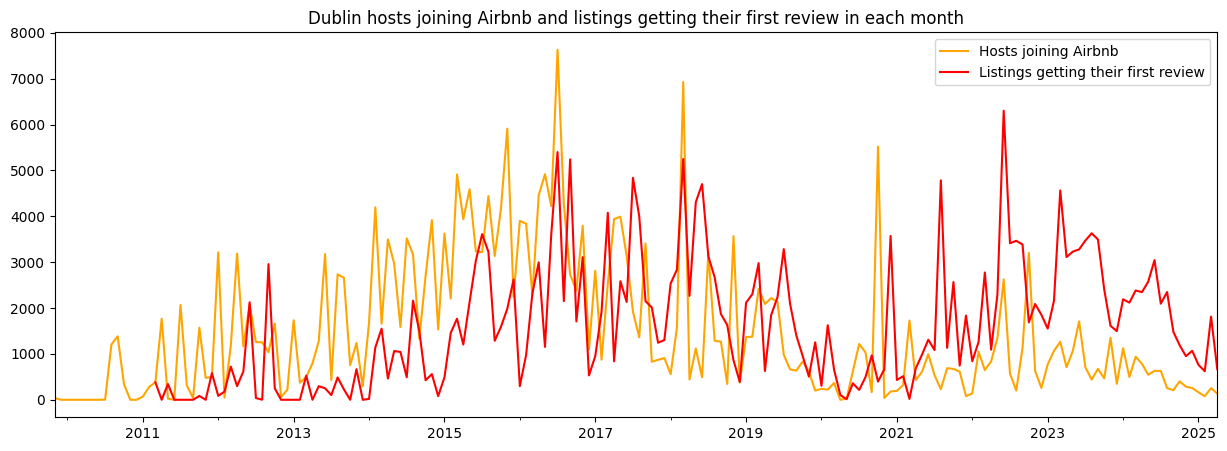

In [39]:
plt.figure(figsize=(15,5))
dublin_merged_df.set_index('host_since').resample('MS').size().plot(label='Hosts joining Airbnb', color='orange')
dublin_merged_df.set_index('first_review').resample('MS').size().plot(label='Listings getting their first review', color='red')
plt.title('Dublin hosts joining Airbnb and listings getting their first review in each month')
plt.legend()
plt.xlim('2009-11-25', '2025-04-30') # Limiting to whole months
plt.xlabel('')
plt.ylabel('')
plt.show()

In [40]:
# Creating dataframes for time series analysis
ts_host_since = pd.DataFrame(dublin_merged_df.set_index('host_since').resample('MS').size())
ts_first_review = pd.DataFrame(dublin_merged_df.set_index('first_review').resample('MS').size())

# Renaming columns
ts_host_since = ts_host_since.rename(columns={0: 'hosts'})
ts_host_since.index.rename('month', inplace=True)
ts_first_review = ts_first_review.rename(columns={0: 'reviews'})
ts_first_review.index.rename('month', inplace=True)

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose
def decompose_time_series(dublin_merged_df, title=''):
    """
    Plots the original time series and its decomposition into trend, seasonal and residual.
    """
    # Decomposing the time series
    decomposition = seasonal_decompose(dublin_merged_df)

    # Getting the trend, seasonality and noise
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid

    # Plotting the original time series and the decomposition
    plt.figure(figsize=(12,8))
    plt.suptitle(title, fontsize=14, y=1)
    plt.subplots_adjust(top=0.80)
    plt.subplot(411)
    plt.plot(dublin_merged_df, label='Original')
    plt.legend(loc='upper left')
    plt.subplot(412)
    plt.plot(trend, label='Trend')
    plt.legend(loc='upper left')
    plt.subplot(413)
    plt.plot(seasonal,label='Seasonality')
    plt.legend(loc='upper left')
    plt.subplot(414)
    plt.plot(residual, label='Residuals')
    plt.legend(loc='upper left')
    plt.tight_layout()

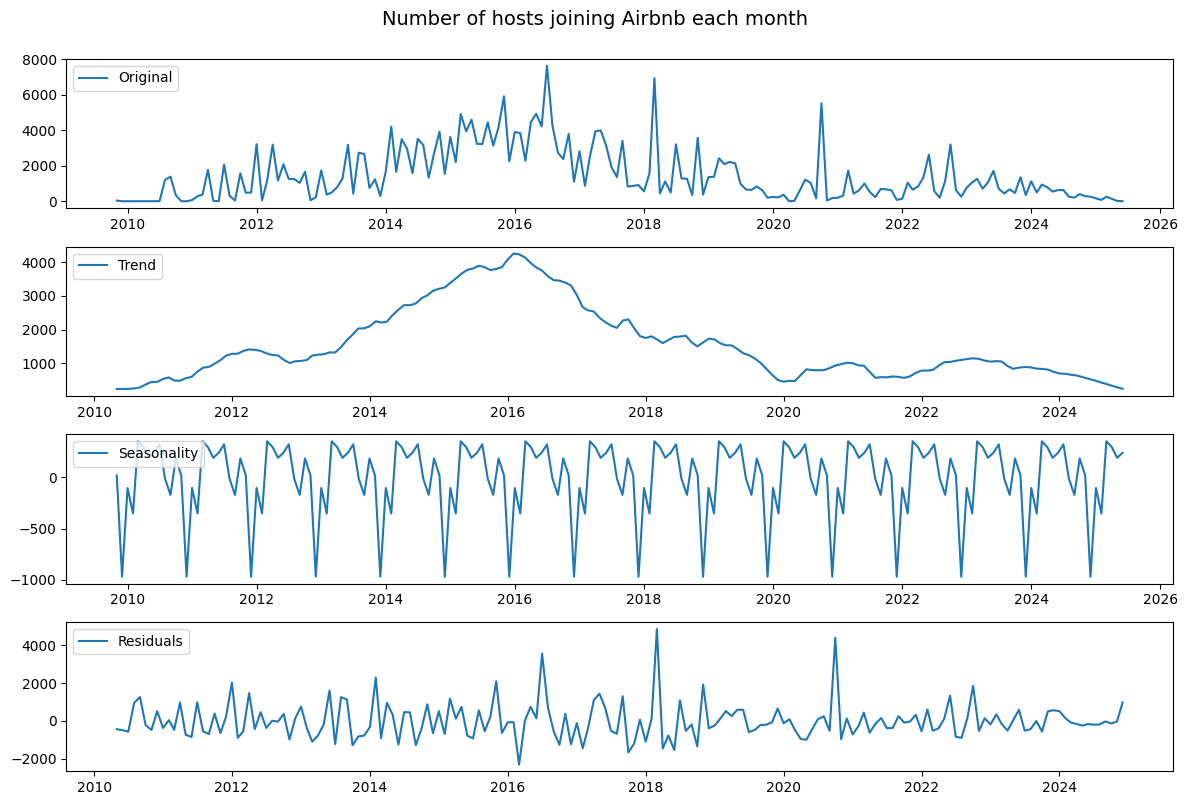

In [42]:
decompose_time_series(ts_host_since, title='Number of hosts joining Airbnb each month')

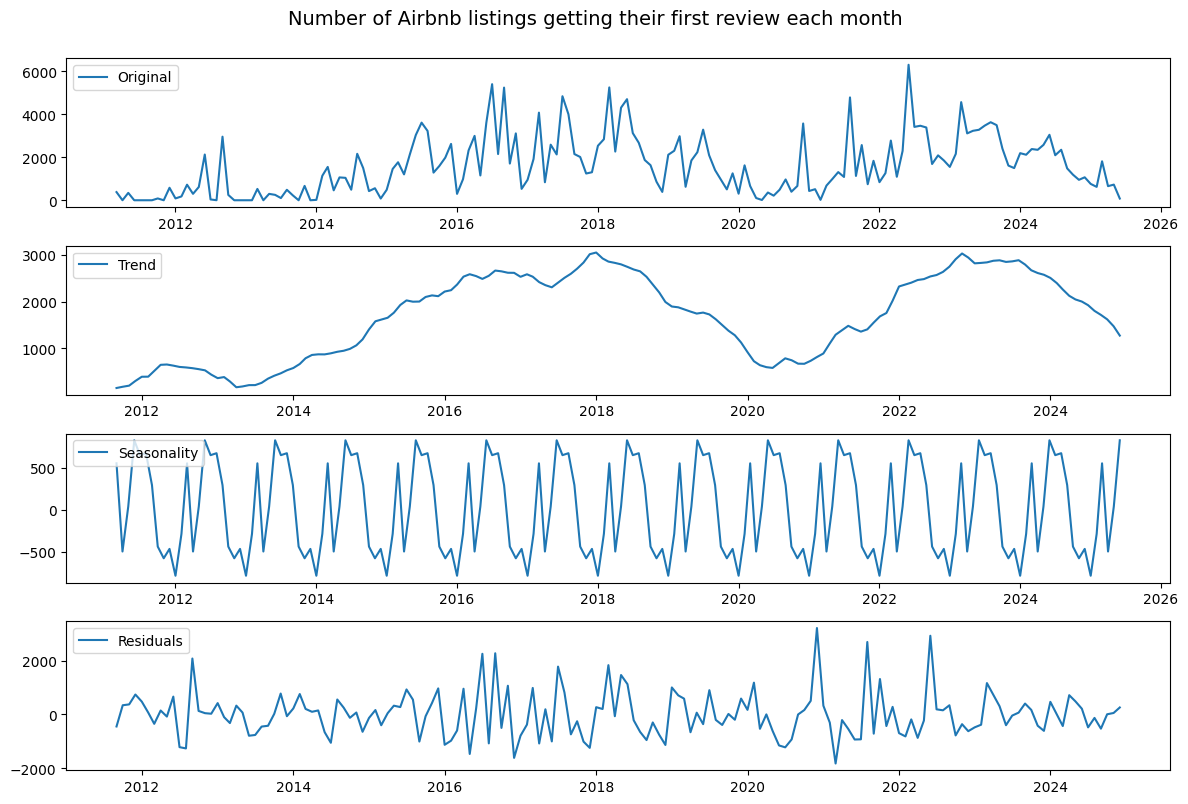

In [43]:

decompose_time_series(ts_first_review, title='Number of Airbnb listings getting their first review each month')

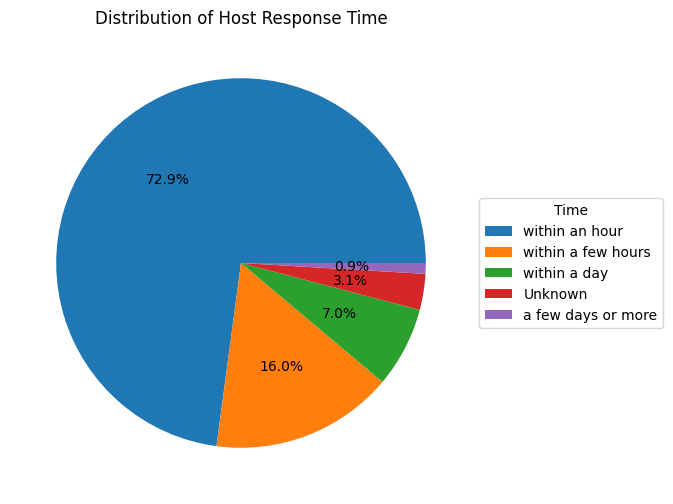

In [44]:
plt.figure(figsize=(10,6))
plt.pie(dublin_merged_df.host_response_time.value_counts(), autopct='%1.1f%%')
plt.title('Distribution of Host Response Time')
plt.legend(labels = dublin_merged_df.host_response_time.value_counts().index, title="Time", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

/tmp/ipykernel_3615/2170755665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, palette='viridis')


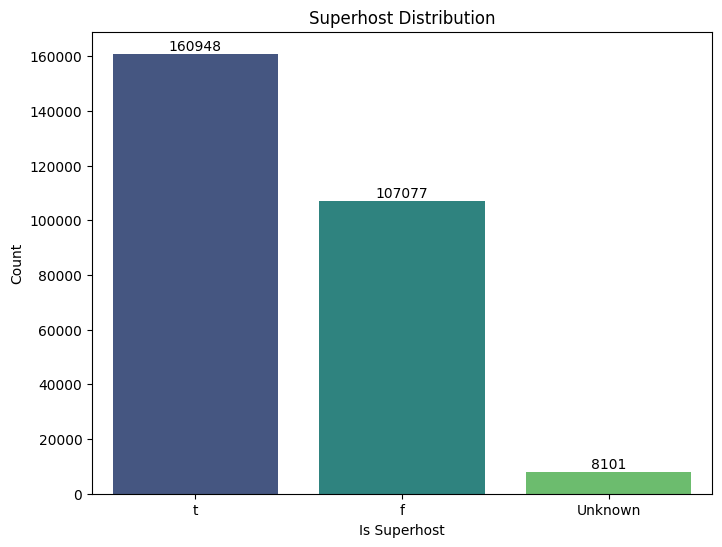

In [45]:
# Create the barplot
plt.figure(figsize=(8,6))

x = dublin_merged_df.host_is_superhost.value_counts().index
y = dublin_merged_df.host_is_superhost.value_counts().values

sns.barplot(x=x, y=y, palette='viridis')

# Add values on top of the bars
for i in range(len(x)):
    plt.text(i, y[i] + 50, str(y[i]), ha='center', va='bottom')

# Add title and labels
plt.title('Superhost Distribution')
plt.ylabel('Count')
plt.xlabel('Is Superhost')

# Display the plot
plt.show()

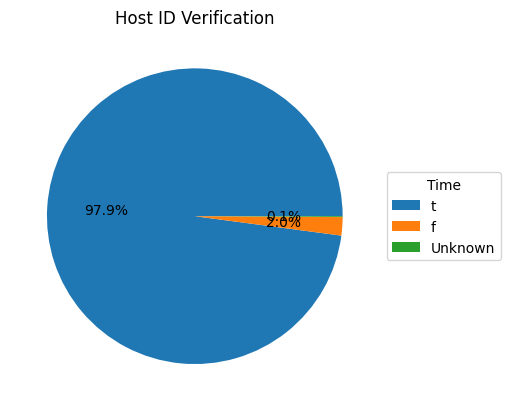

In [46]:
plt.pie(dublin_merged_df.host_identity_verified.value_counts(), autopct='%1.1f%%')
plt.title('Host ID Verification')
plt.legend(labels = dublin_merged_df.host_identity_verified.value_counts().index, title="Time", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

/tmp/ipykernel_3615/4235101588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dublin_merged_df.neighbourhood_cleansed.value_counts().values[:10], y=dublin_merged_df.neighbourhood_cleansed.value_counts().index[:10], palette="gist_earth")


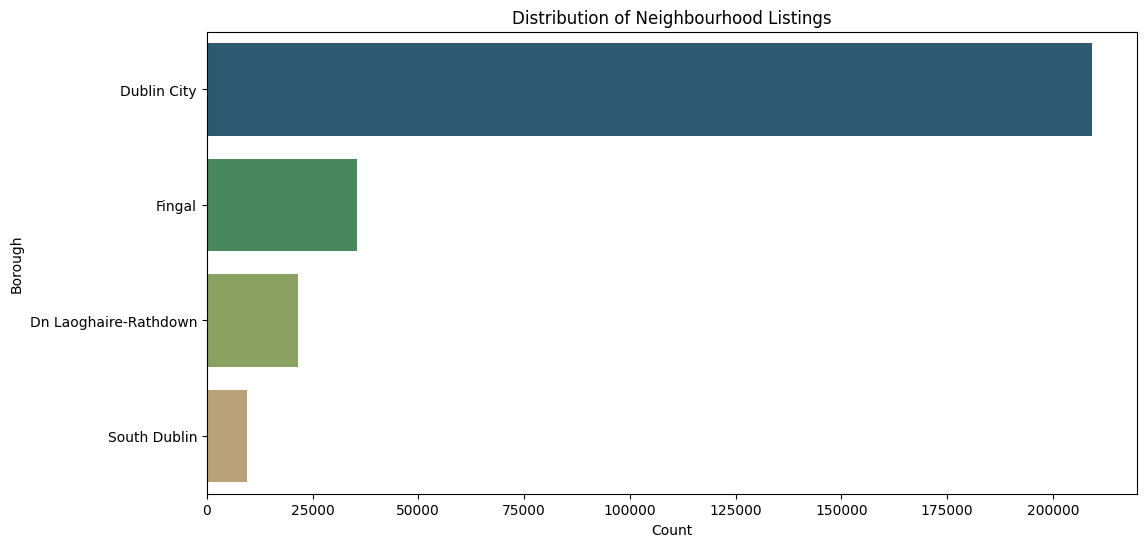

In [47]:
plt.figure(figsize=(12,6))
sns.barplot(x=dublin_merged_df.neighbourhood_cleansed.value_counts().values[:10], y=dublin_merged_df.neighbourhood_cleansed.value_counts().index[:10], palette="gist_earth")
plt.title('Distribution of Neighbourhood Listings')
plt.ylabel('Borough')
plt.xlabel('Count')
plt.show()

In [48]:
'''
# use MarkerCluster
import folium
from folium.plugins import MarkerCluster

# Create map
map_center = [-6.266155, 53.350140]
m = folium.Map(location=map_center, zoom_start=12)

# Create a marker cluster layer
marker_cluster = MarkerCluster().add_to(m)

# Add points to the cluster layer
for idx, row in dublin_merged_df.iterrows():
    folium.Marker(
        [row['latitude'], row['longitude']],
        popup=row['name']
    ).add_to(marker_cluster)

# Display map
'''

"\n# use MarkerCluster\nimport folium\nfrom folium.plugins import MarkerCluster\n\n# Create map\nmap_center = [-6.266155, 53.350140]\nm = folium.Map(location=map_center, zoom_start=12)\n\n# Create a marker cluster layer\nmarker_cluster = MarkerCluster().add_to(m)\n\n# Add points to the cluster layer\nfor idx, row in dublin_merged_df.iterrows():\n    folium.Marker(\n        [row['latitude'], row['longitude']],\n        popup=row['name']\n    ).add_to(marker_cluster)\n\n# Display map\n"

In [49]:
'''
from folium.plugins import HeatMap

# Create list of points
points = dublin_merged_df[['latitude', 'longitude']].values.tolist()

# Add heatmap layer
HeatMap(points).add_to(m)
display(m)
'''

"\nfrom folium.plugins import HeatMap\n\n# Create list of points\npoints = dublin_merged_df[['latitude', 'longitude']].values.tolist()\n\n# Add heatmap layer\nHeatMap(points).add_to(m)\ndisplay(m)\n"

In [ ]:

# Save the map
# m.save('my_heatmap.html')

Room Type Distribution

/tmp/ipykernel_3615/1023304732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dublin_merged_df.room_type.value_counts().values[:10], y=dublin_merged_df.room_type.value_counts().index[:10], palette="CMRmap")


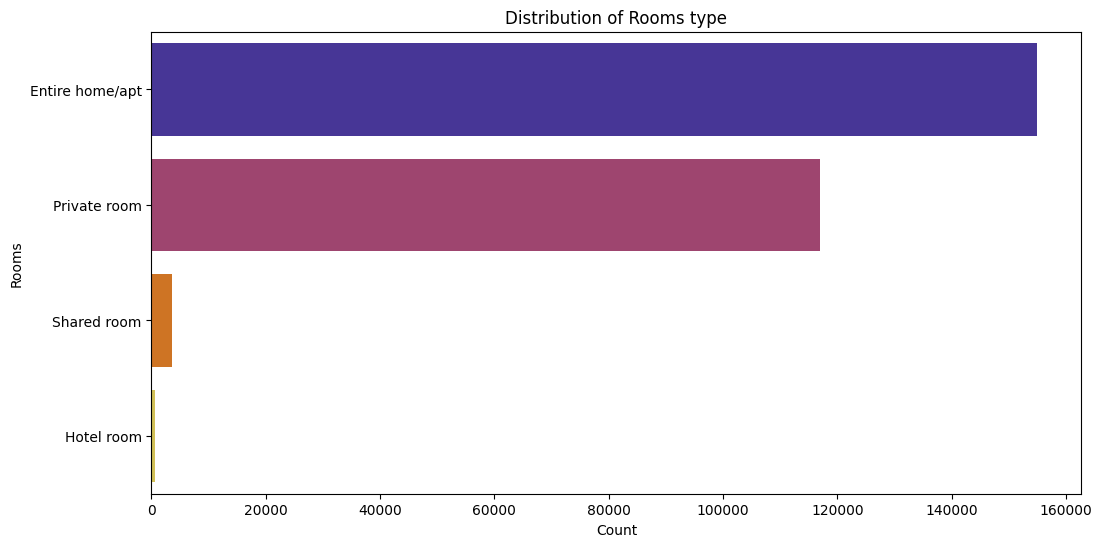

In [50]:
plt.figure(figsize=(12,6))
sns.barplot(x=dublin_merged_df.room_type.value_counts().values[:10], y=dublin_merged_df.room_type.value_counts().index[:10], palette="CMRmap")
plt.title('Distribution of Rooms type')
plt.ylabel('Rooms')
plt.xlabel('Count')
plt.show()

Bookable Distribution

/tmp/ipykernel_3615/2075270602.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, palette='prism_r')


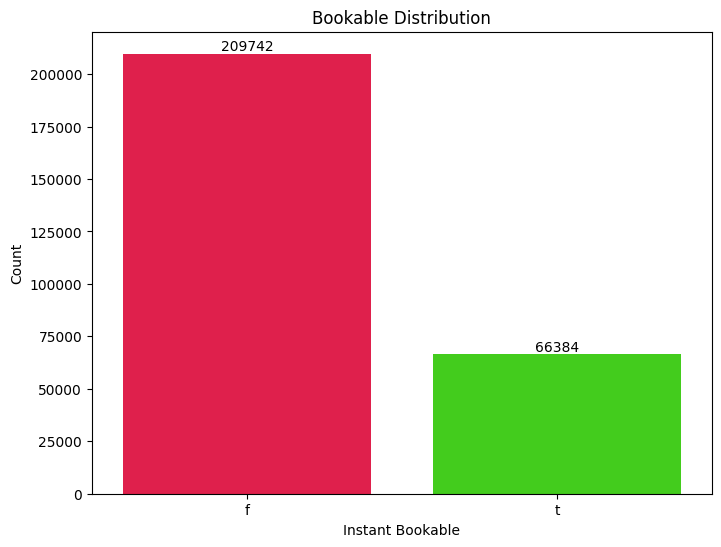

In [51]:
# Create the barplot
plt.figure(figsize=(8,6))

x = dublin_merged_df.instant_bookable.value_counts().index
y = dublin_merged_df.instant_bookable.value_counts().values

sns.barplot(x=x, y=y, palette='prism_r')

# Add values on top of the bars
for i in range(len(x)):
    plt.text(i, y[i] + 50, str(y[i]), ha='center', va='bottom')

# Add title and labels
plt.title('Bookable Distribution')
plt.ylabel('Count')
plt.xlabel('Instant Bookable')

# Display the plot
plt.show()


Price Distribution after addressing outlier

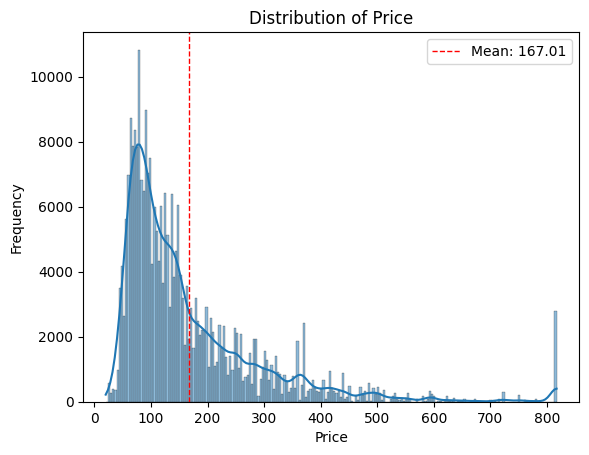

In [52]:
# mean of the 'price' column
mean_value = dublin_merged_df['price'].mean()

# histogram
sns.histplot(dublin_merged_df['price'], kde=True)

# Add a vertical line at the mean
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_value:.2f}')

# Add legend and labels
plt.legend()
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')

plt.show();

**Feature Engineering**

Sentiment Analysis (VADER)
Five basic preprocessing methods was carried out on the guest reviews (comment) these steps were carried so that model evaluation can produce correct and inadequate performance, increase the data quality and remove noise.

In [53]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Ensure resources are available
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [54]:
# 1. Case Folding
dublin_merged_df['comments'] = dublin_merged_df['comments'].astype(str).str.lower()

In [55]:
# 2. Remove Noise (Numbers and text in square brackets)
def remove_noise(text):
    text = re.sub(r'\[.*?\]', '', text) # Remove text in brackets
    text = re.sub(r'\d+', '', text)     # Remove numbers
    return text

dublin_merged_df['comments'] = dublin_merged_df['comments'].apply(remove_noise)

In [56]:
# 3. Non-ASCII Removal (Filtering for English-only characters)
def remove_non_ascii(text):
    return text.encode("ascii", "ignore").decode()

dublin_merged_df['comments'] = dublin_merged_df['comments'].apply(remove_non_ascii)


In [57]:
# 4. Normalization (Slang to Formal)
# Here is a representative sample mapping:
slang_dict = {"u": "you", "r": "are", "brb": "be right back", "thx": "thanks", "plz": "please"}
def normalize_slang(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

dublin_merged_df['comments'] = dublin_merged_df['comments'].apply(normalize_slang)

In [58]:
# 5. Stopword Removal (Including your specified noise words)
stop_words = set(stopwords.words('english'))
# Adding specific noise mentioned in your methodology
custom_noise = {"jeudidi", "ghh", "owo"}
stop_words.update(custom_noise)

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

dublin_merged_df['comments'] = dublin_merged_df['comments'].apply(remove_stopwords)

# Final reduction check
dublin_merged_df = dublin_merged_df[dublin_merged_df['comments'].str.strip() != ""]

Sentiment score (compound score) the VADER sentiment analysis tool was used to capture the emotional tone of the guest reviews. Then for each guest review, a compound sentiment score was computed using VADER’s polarity_scores() method, which is a weighted composite that ranges from -1 (extremely negative) to +1 (extremely positive), such that Compound scores ≥ 0.05 are Positive, Compound scores > -0.05 and < 0.05 are Neutral and then Compound scores ≤ -0.05 Negative.



In [59]:
# initialize vader Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

In [60]:
# feature engineer and introduce a new column sentiment score
dublin_merged_df['compound_scores'] = dublin_merged_df['comments'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
dublin_merged_df.head(2)

,id_x,listing_url,description,picture_url,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_value,instant_bookable,reviews_per_month,listing_id,id_y,date,reviewer_id,reviewer_name,comments,compound_scores
0,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,within a few hours,100.0,99.0,t,2.0,...,4.82,f,2.19,44077,203703,2011-03-20,393348,Christian,"enjoyed stay much. room comfortable, neat clea...",0.9612
1,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,within a few hours,100.0,99.0,t,2.0,...,4.82,f,2.19,44077,211369,2011-03-28,444004,Solidea,nights. stay home best way improve english. <b...,0.9838


Sentiment Score Distribution

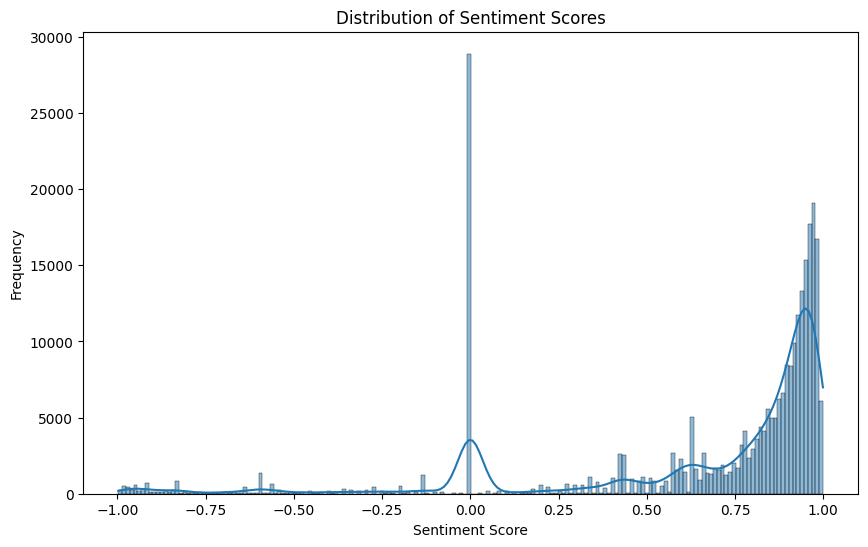

In [61]:
# check the distribution of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(dublin_merged_df['compound_scores'], kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

Sentiment Distribution in Pia chart

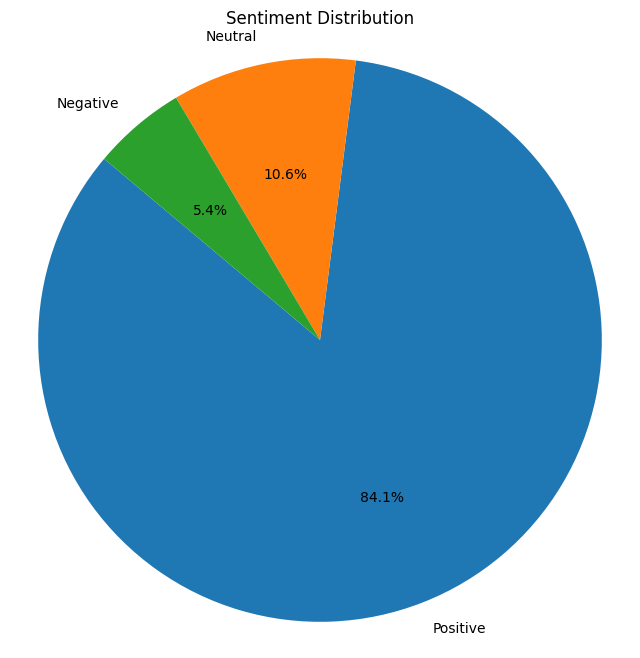

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

sentiment_bins = [-1, -0.05, 0.05, 1]
sentiment_labels = ['Negative', 'Neutral', 'Positive']

dublin_merged_df['sentiment_category'] = pd.cut(
    dublin_merged_df['compound_scores'],
    bins=sentiment_bins,
    labels=sentiment_labels
)

sentiment_counts = dublin_merged_df['sentiment_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Sentiment Distribution')
plt.axis('equal')  # makes the pie circular
plt.show()


Average Price Per Month Distribution

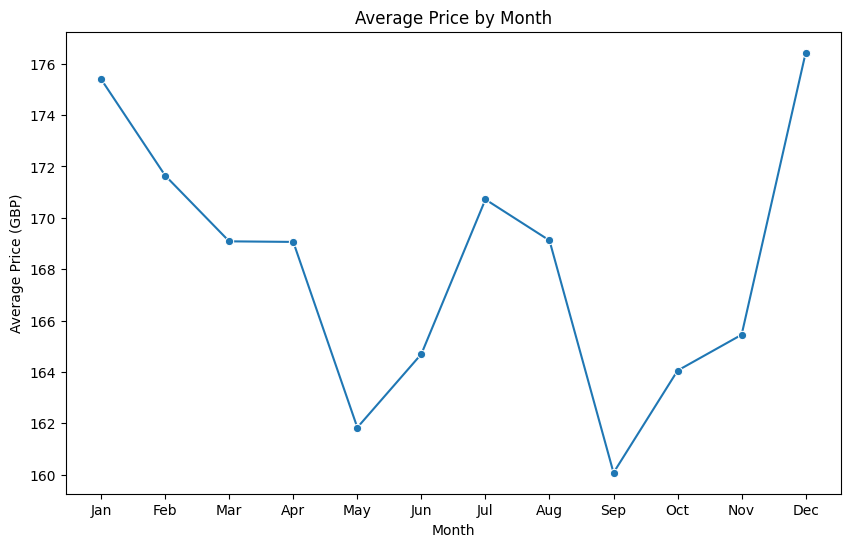

In [63]:
# month
dublin_merged_df['month'] = dublin_merged_df['date'].dt.month

# Calculate average price per month
avg_price_per_month = dublin_merged_df.groupby('month')['price'].mean().reset_index()

# Create a line plot
plt.figure(figsize=(10,6))
sns.lineplot(x='month', y='price', data=avg_price_per_month, marker='o')

# labels and title
plt.title('Average Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price (GBP)')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
# Show the plot
plt.show();

Season Feature

In [64]:
# Ensuring date column is in datetime format
dublin_merged_df['date'] = pd.to_datetime(dublin_merged_df['date'])

# function to categorize seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Autumn'

# Apply the function to create a 'season' column
dublin_merged_df['season'] = dublin_merged_df['date'].dt.month.apply(get_season)

/tmp/ipykernel_3615/2398385479.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('season')['price']
/tmp/ipykernel_3615/2398385479.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='season', y='price', data=avg_price_per_season, palette='Spectral')


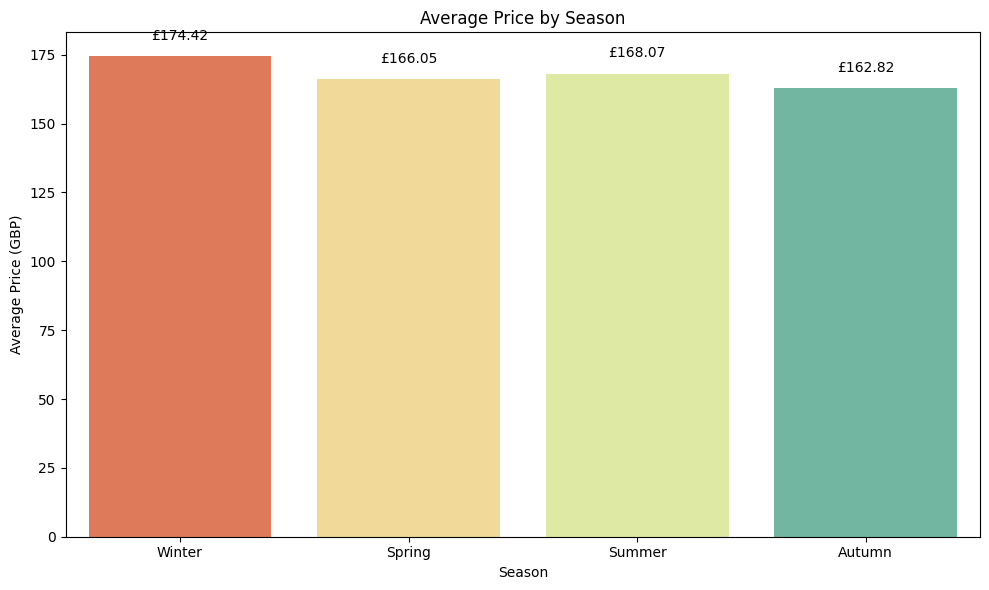

In [65]:
# Ensure 'season' is a category with proper order
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
dublin_merged_df['season'] = pd.Categorical(dublin_merged_df['season'], categories=season_order, ordered=True)

# Calculate average price per season
avg_price_per_season = (
    dublin_merged_df
    .groupby('season')['price']
    .mean()
    .reset_index()
    .sort_values(by='price')
)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='season', y='price', data=avg_price_per_season, palette='Spectral')

# Add labels on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"£{height:.2f}",
        ha='center',
        va='bottom',
        color='black'
    )

# Add labels and title
ax.set_title('Average Price by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Average Price (GBP)')

plt.tight_layout()
plt.show()

In [66]:
dublin_merged_df['season'].value_counts()

,count
season,
Summer,82236
Spring,81414
Autumn,70641
Winter,41078


In [67]:
dublin_merged_df = pd.get_dummies(dublin_merged_df, columns=['season'], drop_first=True)

In [68]:
dublin_merged_df[['season_Spring', 'season_Summer', 'season_Autumn']].head()

,season_Spring,season_Summer,season_Autumn
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [69]:
bool_columns = ['season_Spring', 'season_Summer', 'season_Autumn']
dublin_merged_df[bool_columns] = dublin_merged_df[bool_columns].astype(int)

**Distance to City Centers**

A spatial feature measuring distance to Dublin city centre was engineered to capture the effect of geographical proximity on accommodation price

In [70]:
from geopy.distance import geodesic

city_center = (53.3498, -6.2603)  # Dublin
dublin_merged_df['distance_to_center'] = dublin_merged_df.apply(
    lambda x: geodesic((x['latitude'], x['longitude']), city_center).km,
    axis=1
)

In [71]:
dublin_merged_df['distance_to_center'].head()

,distance_to_center
0,6.459127
1,6.459127
2,6.459127
3,6.459127
4,6.459127


The scattered plot illustrates the relationship between accommodation price and distance from Dublin city centre. A clear downward trend is observed, indicating that listings closer to the city centre command higher prices, while those located further away tend to be cheaper. High-price outliers are concentrated near the city centre, suggesting that proximity to central business districts and tourist attractions allows hosts to charge premium rates. This empirical pattern supports the inclusion of a distance-to-centre feature in the predictive model

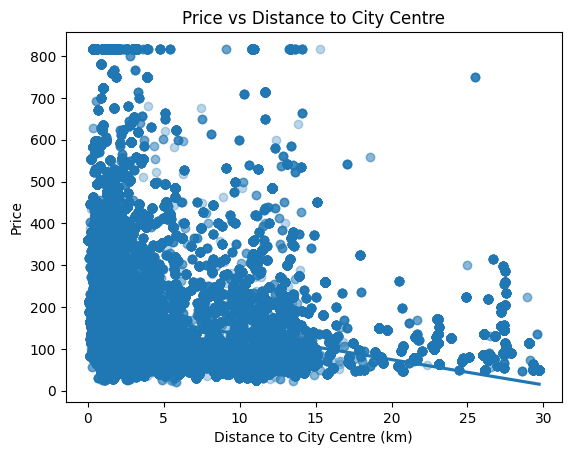

In [72]:
import seaborn as sns

sns.regplot(x='distance_to_center', y='price', data=dublin_merged_df,
            scatter_kws={'alpha':0.3})
plt.xlabel("Distance to City Centre (km)")
plt.ylabel("Price")
plt.title("Price vs Distance to City Centre")
plt.show()

In [73]:
corr = dublin_merged_df["distance_to_center"].corr(dublin_merged_df["compound_scores"])
print(f"Correlation between distance and sentiment: {corr:.3f}")


Correlation between distance and sentiment: 0.024


**Feature Encoding**

Feature encoding is performed because the  machine learning algorithms used in this project can only process numerical inputs.

Binary host attributes (superhost status, instant booking availability, profile picture presence, and identity verification) were encoded as 0/1 indicator variables. Missing values were treated as the absence of the attribute, reflecting platform logic and ensuring consistent interpretation across listings.

In [74]:
dublin_merged_df[['host_is_superhost', 'instant_bookable', 'host_has_profile_pic', 'host_identity_verified']].head()

,host_is_superhost,instant_bookable,host_has_profile_pic,host_identity_verified
0,t,f,t,t
1,t,f,t,t
2,t,f,t,t
3,t,f,t,t
4,t,f,t,t


In [75]:
# Binary host/listing features
binary_cols = [
    'host_is_superhost',
    'instant_bookable',
    'host_has_profile_pic',
    'host_identity_verified'
]

for col in binary_cols:
    dublin_merged_df[col] = dublin_merged_df[col].astype(str).str.lower()
    dublin_merged_df[col] = dublin_merged_df[col].map({
        't': 1, 'true': 1, '1': 1,
        'f': 0, 'false': 0, '0': 0
    })
    dublin_merged_df[col] = dublin_merged_df[col].fillna(0).astype(int)

# Fill missing first
dublin_merged_df['host_response_time'] = dublin_merged_df['host_response_time'].fillna('unknown')

# Clean text: strip spaces and lowercase
dublin_merged_df['host_response_time'] = dublin_merged_df['host_response_time'].astype(str).str.strip().str.lower()

# Ordinal mapping
response_map = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1,
    'unknown': 0
}

# Map values; unmapped categories become 0
dublin_merged_df['host_response_time'] = dublin_merged_df['host_response_time'].map(response_map).fillna(0).astype(int)

# Check
dublin_merged_df['host_response_time'].value_counts()

# Check result
#print(dublin_merged_df[binary_cols + ['host_response_time']].head())


,count
host_response_time,
4,200652
3,44063
2,19404
0,8663
1,2587


In [76]:
print("Unique neighbourhoods:", dublin_merged_df['neighbourhood_cleansed'].nunique())
print("Unique room types:", dublin_merged_df['room_type'].nunique())

Unique neighbourhoods: 4
Unique room types: 4


In [77]:
ohe_cols = ["neighbourhood_cleansed", "room_type"]

dublin_merged_df = pd.get_dummies(
    dublin_merged_df,
    columns=ohe_cols,
    drop_first=False,
    dtype=int
)

In [78]:
dublin_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275369 entries, 0 to 310099
Data columns (total 64 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   id_x                                          275369 non-null  int64         
 1   listing_url                                   275369 non-null  object        
 2   description                                   275369 non-null  object        
 3   picture_url                                   275369 non-null  object        
 4   host_since                                    275369 non-null  datetime64[ns]
 5   host_response_time                            275369 non-null  int64         
 6   host_response_rate                            275369 non-null  float64       
 7   host_acceptance_rate                          275369 non-null  float64       
 8   host_is_superhost                             275369 non-nu

In [79]:
dublin_merged_df.columns

Index(['id_x', 'listing_url', 'description', 'picture_url', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'number_of_reviews',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review',
       'last_review', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'reviews_per_month',
       'listing_id', 'id_y', 'date', 'reviewer_id', 'reviewer_name',

**Data Aggregation**

Data were grouped by listing ID to create one record per property. Fixed attributes (e.g. bedrooms, room type and neighbourhood indicators) were retained using the first observed value, while time-varying variables (e.g. price, review scores and sentiment measures) were averaged to obtain representative property-level values.

In [80]:
dublin_aggregated_df = (
    dublin_merged_df
    .groupby('id_x')
    .agg({
    'price': 'first',
    'host_response_time': 'first',
    'host_response_rate': 'first',
    'host_acceptance_rate': 'first',
    'host_is_superhost': 'first',
    'host_listings_count': 'first',
    'host_has_profile_pic': 'first',
    'host_identity_verified': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'accommodates': 'first',
    'bathrooms': 'first',
    'bedrooms': 'first',
    'beds': 'first',
    'minimum_nights': 'first',
    'maximum_nights': 'first',
    'availability_30': 'first',
    'availability_60': 'first',
    'availability_90': 'first',
    'availability_365': 'first',
    'availability_eoy': 'first',
    'number_of_reviews': 'first',
    'number_of_reviews_l30d': 'first',
    'number_of_reviews_ly': 'first',
    'estimated_occupancy_l365d': 'first',
    'estimated_revenue_l365d': 'first',
    'review_scores_rating': 'first',
    'review_scores_accuracy': 'first',
    'review_scores_cleanliness': 'first',
    'review_scores_checkin': 'first',
    'review_scores_communication': 'first',
    'review_scores_location': 'first',
    'review_scores_value': 'first',
    'instant_bookable': 'first',
    'reviews_per_month': 'first',
    'distance_to_center': 'first',

    # Neighbourhood dummies
    'neighbourhood_cleansed_Dn Laoghaire-Rathdown': 'first',
    'neighbourhood_cleansed_Dublin City': 'first',
    'neighbourhood_cleansed_Fingal': 'first',
    'neighbourhood_cleansed_South Dublin': 'first',

    # Room type dummies
    'room_type_Entire home/apt': 'first',
    'room_type_Hotel room': 'first',
    'room_type_Private room': 'first',
    'room_type_Shared room': 'first',

    # Review-derived features
    'compound_scores': 'mean',
    'season_Spring': 'mean',
    'season_Summer': 'mean',
    'season_Autumn': 'mean'
    })
        .reset_index()
)

In [81]:
dublin_aggregated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 49 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id_x                                          4459 non-null   int64  
 1   price                                         4459 non-null   float64
 2   host_response_time                            4459 non-null   int64  
 3   host_response_rate                            4459 non-null   float64
 4   host_acceptance_rate                          4459 non-null   float64
 5   host_is_superhost                             4459 non-null   int64  
 6   host_listings_count                           4459 non-null   float64
 7   host_has_profile_pic                          4459 non-null   int64  
 8   host_identity_verified                        4459 non-null   int64  
 9   latitude                                      4459 non-null   f

Price Distribution after Data Aggregate.

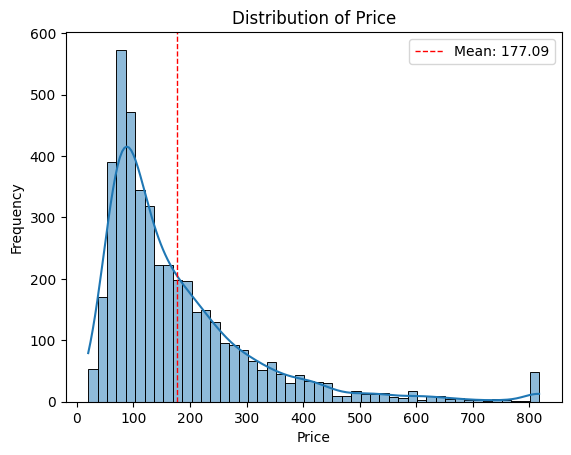

In [82]:
# mean of the 'price' column
mean_value = dublin_aggregated_df['price'].mean()

# histogram
sns.histplot(dublin_aggregated_df['price'], kde=True)

# Add a vertical line at the mean
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_value:.2f}')

# Add legend and labels
plt.legend()
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')

plt.show();

**New feature correlation**

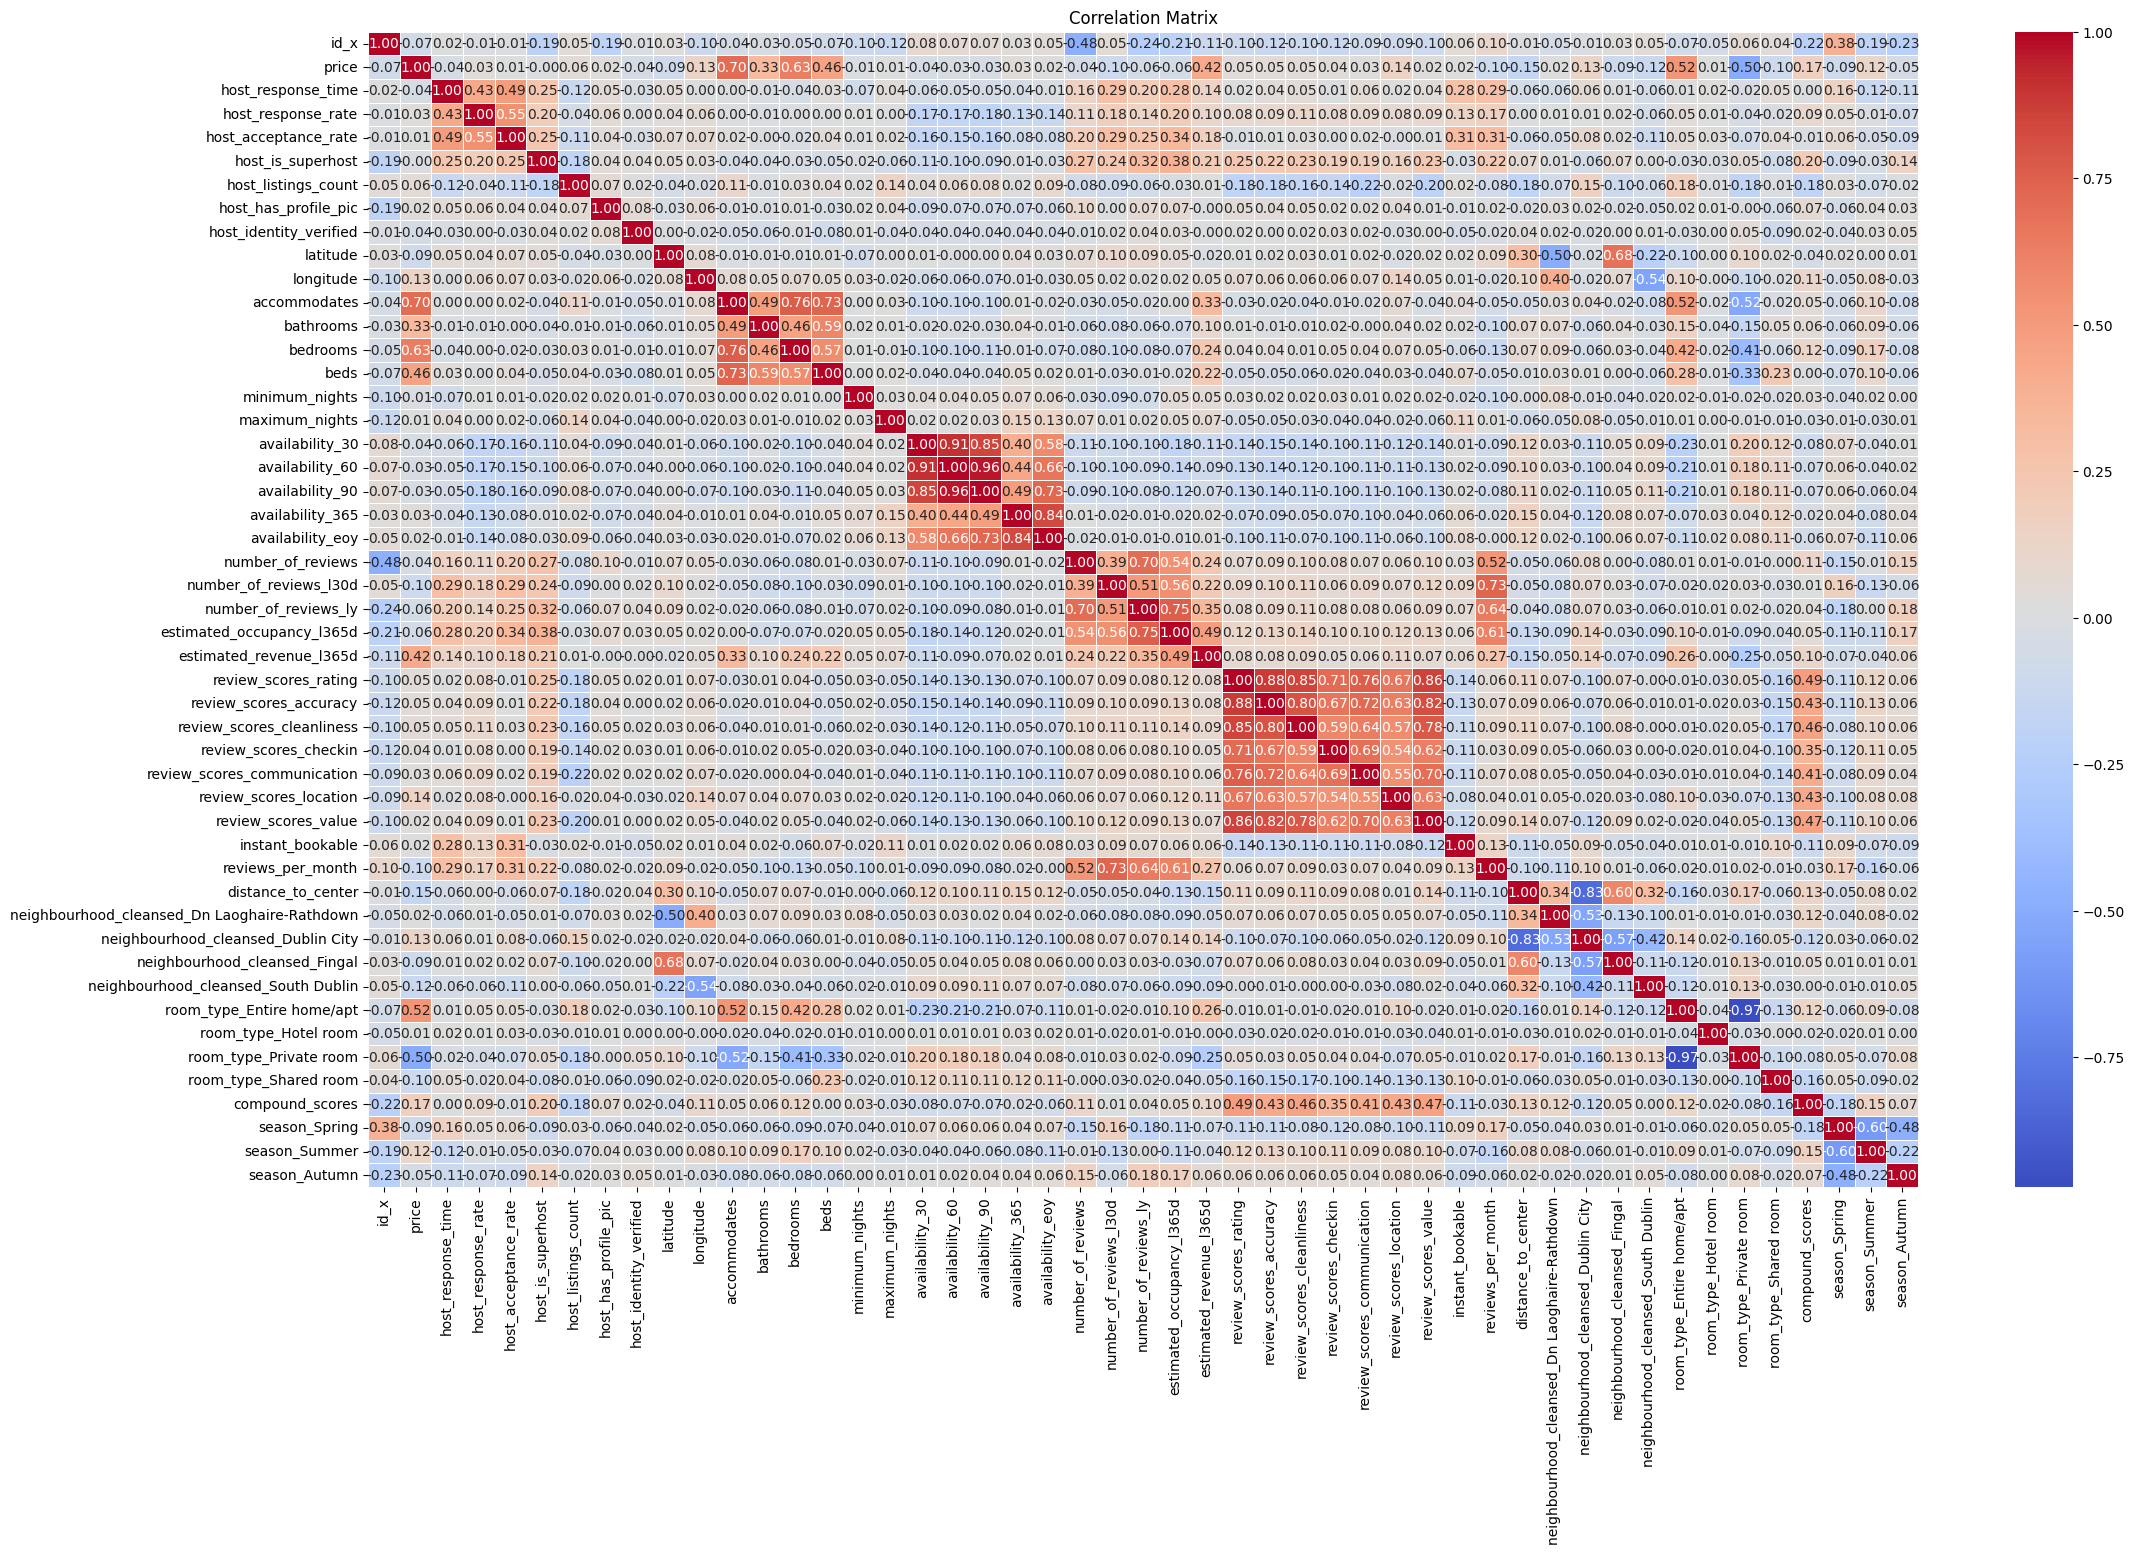

In [83]:
# correlation heat map for numerical variable

# Filter the dataframe to select only numeric columns
numeric_df = dublin_aggregated_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(25, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

**Base Line Model**

R2: 0.6759885248531486
MAE: 50.396961612346985
RMSE: 79.67420330078406


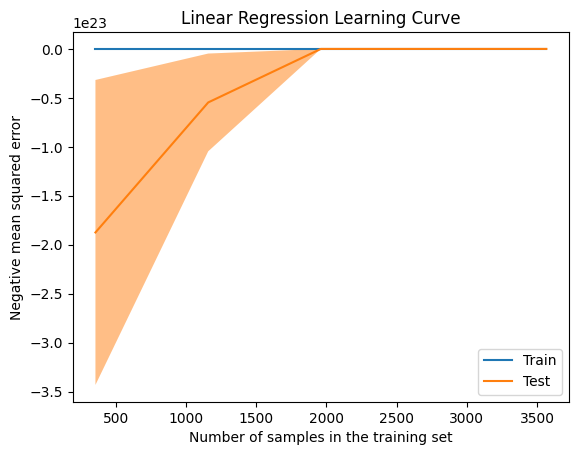

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import LearningCurveDisplay

X = dublin_aggregated_df.drop(columns=['price'])
y = dublin_aggregated_df.loc[X.index, 'price']   # align with selected rows

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Learning Curve
LearningCurveDisplay.from_estimator(
    pipe_lr, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Linear Regression Learning Curve")
plt.show()

Feature Selection Using LASSO Regression

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline


In [86]:
# Target
y = dublin_aggregated_df['price']

# Drop non-predictive or leakage columns
drop_cols = [
    'price', 'listing_url', 'picture_url', 'description', 'availability_eoy', 'availability_30', 'availability_60',
    'availability_90', 'availability_365', 'reviewer_name', 'host_since', 'first_review', 'last_review', 'estimated_revenue_l365d',
    'date', 'amenities', 'listing_id', 'id_x', 'id_y', 'reviewer_id', 'latitude', 'longitude'
]

X = dublin_aggregated_df.drop(columns=drop_cols, errors='ignore')

# Keep only numeric columns (LASSO needs numeric)
X = X.select_dtypes(include=['int64', 'float64', 'bool'])


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', LassoCV(cv=5, n_jobs=-1, random_state=42))])

In [88]:
lasso = pipeline.named_steps['lasso']
coef = pd.Series(lasso.coef_, index=X.columns)

selected_features = coef[coef != 0].sort_values(key=abs, ascending=False)

selected_features


,0
accommodates,67.430332
bedrooms,30.792678
room_type_Entire home/apt,23.207833
distance_to_center,-19.969461
estimated_occupancy_l365d,-18.061539
compound_scores,12.922918
beds,-10.255262
review_scores_cleanliness,8.146889
number_of_reviews_ly,6.483610
host_is_superhost,6.157568


In [89]:
# Filter for coefficients that are exactly zero
dropped_features = coef[coef == 0].index.tolist()

print(f"Number of features dropped: {len(dropped_features)}")
print(dropped_features)

Number of features dropped: 8
['host_acceptance_rate', 'review_scores_rating', 'review_scores_checkin', 'neighbourhood_cleansed_Dn Laoghaire-Rathdown', 'neighbourhood_cleansed_Dublin City', 'neighbourhood_cleansed_Fingal', 'room_type_Private room', 'season_Summer']


In [90]:
print(f"Total features: {X.shape[1]}")
print(f"Selected features: {selected_features.shape[0]}")
print("\nSelected features:\n")
print(selected_features)


Total features: 39
Selected features: 31

Selected features:

accommodates                           67.430332
bedrooms                               30.792678
room_type_Entire home/apt              23.207833
distance_to_center                    -19.969461
estimated_occupancy_l365d             -18.061539
compound_scores                        12.922918
beds                                  -10.255262
review_scores_cleanliness               8.146889
number_of_reviews_ly                    6.483610
host_is_superhost                       6.157568
host_response_time                     -6.079620
host_listings_count                    -5.653516
review_scores_value                    -5.174595
review_scores_communication            -4.954233
review_scores_location                  4.868319
host_response_rate                      4.632866
instant_bookable                        3.709029
neighbourhood_cleansed_South Dublin    -3.252809
room_type_Hotel room                    3.201909
season_

In [91]:
X_selected = X[selected_features.index]


In [92]:
X_selected.columns

Index(['accommodates', 'bedrooms', 'room_type_Entire home/apt',
       'distance_to_center', 'estimated_occupancy_l365d', 'compound_scores',
       'beds', 'review_scores_cleanliness', 'number_of_reviews_ly',
       'host_is_superhost', 'host_response_time', 'host_listings_count',
       'review_scores_value', 'review_scores_communication',
       'review_scores_location', 'host_response_rate', 'instant_bookable',
       'neighbourhood_cleansed_South Dublin', 'room_type_Hotel room',
       'season_Autumn', 'room_type_Shared room', 'number_of_reviews',
       'minimum_nights', 'number_of_reviews_l30d', 'bathrooms',
       'reviews_per_month', 'host_has_profile_pic', 'season_Spring',
       'host_identity_verified', 'review_scores_accuracy', 'maximum_nights'],
      dtype='object')

In [93]:
X_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   accommodates                         4459 non-null   int64  
 1   bedrooms                             4459 non-null   float64
 2   room_type_Entire home/apt            4459 non-null   int64  
 3   distance_to_center                   4459 non-null   float64
 4   estimated_occupancy_l365d            4459 non-null   int64  
 5   compound_scores                      4459 non-null   float64
 6   beds                                 4459 non-null   float64
 7   review_scores_cleanliness            4459 non-null   float64
 8   number_of_reviews_ly                 4459 non-null   int64  
 9   host_is_superhost                    4459 non-null   int64  
 10  host_response_time                   4459 non-null   int64  
 11  host_listings_count           

In [94]:
y_test

,price
297,326.0
2268,191.0
2413,303.0
3541,69.0
3915,81.0
...,...
4101,148.0
1616,200.0
1620,48.0
1634,328.0


In [95]:
# Save the X_test dataframe to a CSV file
y_test.to_csv('price_test_data.csv', index=False)

print("File 'price_test_data.csv' has been saved successfully.")


File 'price_test_data.csv' has been saved successfully.


In [96]:
X_selected.describe()

,accommodates,bedrooms,room_type_Entire home/apt,distance_to_center,estimated_occupancy_l365d,compound_scores,beds,review_scores_cleanliness,number_of_reviews_ly,host_is_superhost,...,number_of_reviews,minimum_nights,number_of_reviews_l30d,bathrooms,reviews_per_month,host_has_profile_pic,season_Spring,host_identity_verified,review_scores_accuracy,maximum_nights
count,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,...,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000
mean,3.264409,1.549226,0.550572,5.137092,98.820588,0.623858,1.983404,4.696894,15.407490,0.352770,...,61.930253,4.899305,1.886073,1.349181,1.886140,0.943037,0.371570,0.981834,4.766627,362.011886
std,2.151468,1.014470,0.497492,5.090376,90.834354,0.245596,1.888952,0.466832,22.579875,0.477885,...,108.742442,20.552288,2.558518,0.954473,2.037192,0.231799,0.280116,0.133565,0.406326,390.424597
min,1.000000,0.000000,0.000000,0.022259,0.000000,-0.976100,0.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,1.000000,0.000000,1.427900,18.000000,0.523213,1.000000,4.630000,1.000000,0.000000,...,5.000000,1.000000,0.000000,1.000000,0.480000,1.000000,0.215951,1.000000,4.720000,30.000000
50%,2.000000,1.000000,1.000000,3.007011,66.000000,0.668827,1.000000,4.830000,6.000000,0.000000,...,21.000000,2.000000,1.000000,1.000000,1.210000,1.000000,0.309406,1.000000,4.880000,365.000000
75%,4.000000,2.000000,1.000000,8.270977,168.000000,0.782772,2.000000,4.970000,21.000000,1.000000,...,70.000000,3.000000,3.000000,1.500000,2.650000,1.000000,0.482759,1.000000,4.990000,365.000000
max,16.000000,17.000000,1.000000,29.722236,255.000000,0.996600,50.000000,5.000000,208.000000,1.000000,...,1751.000000,729.000000,31.000000,40.000000,31.930000,1.000000,1.000000,1.000000,5.000000,1125.000000


In [97]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import LearningCurveDisplay

R2: 0.5846393970207302
MAE: 54.89929209366862
RMSE: 90.20906560681007


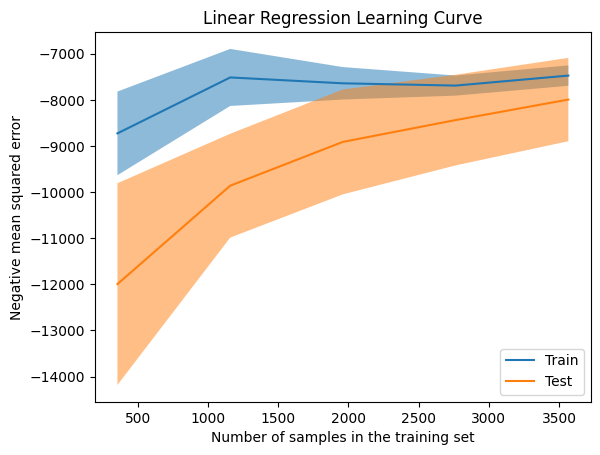

In [98]:
X = X_selected
y = dublin_aggregated_df.loc[X.index, 'price']   # align with selected rows

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Learning Curve
LearningCurveDisplay.from_estimator(
    pipe_lr, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Linear Regression Learning Curve")
plt.show()

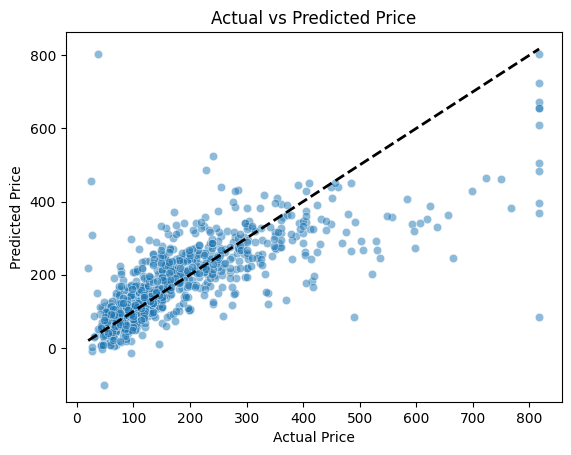

In [99]:
sns.scatterplot(x=y_test, y=y_pred, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

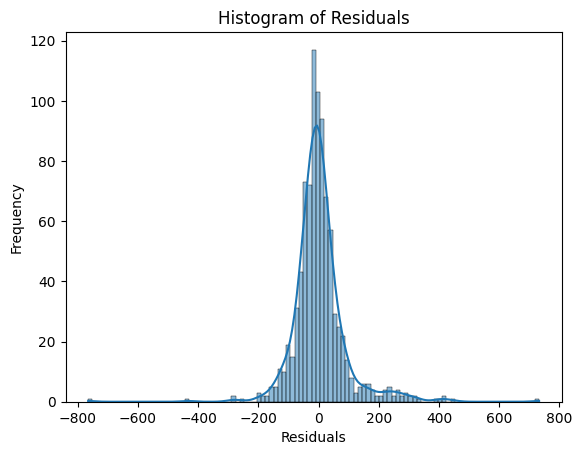

In [100]:
residuals = y_test - y_pred
residuals

sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


In [101]:
# Get coefficients from the trained model
coef = pipe_lr.named_steps['lr'].coef_

feature_importance = pd.Series(coef, index=X.columns)

# Sort by absolute importance
feature_importance = feature_importance.sort_values(key=np.abs, ascending=False)

feature_importance


,0
accommodates,68.604066
bedrooms,31.290406
room_type_Entire home/apt,23.472345
distance_to_center,-20.572053
estimated_occupancy_l365d,-20.360605
compound_scores,13.388528
beds,-11.607263
number_of_reviews_ly,9.891801
review_scores_cleanliness,9.341045
review_scores_value,-7.889152


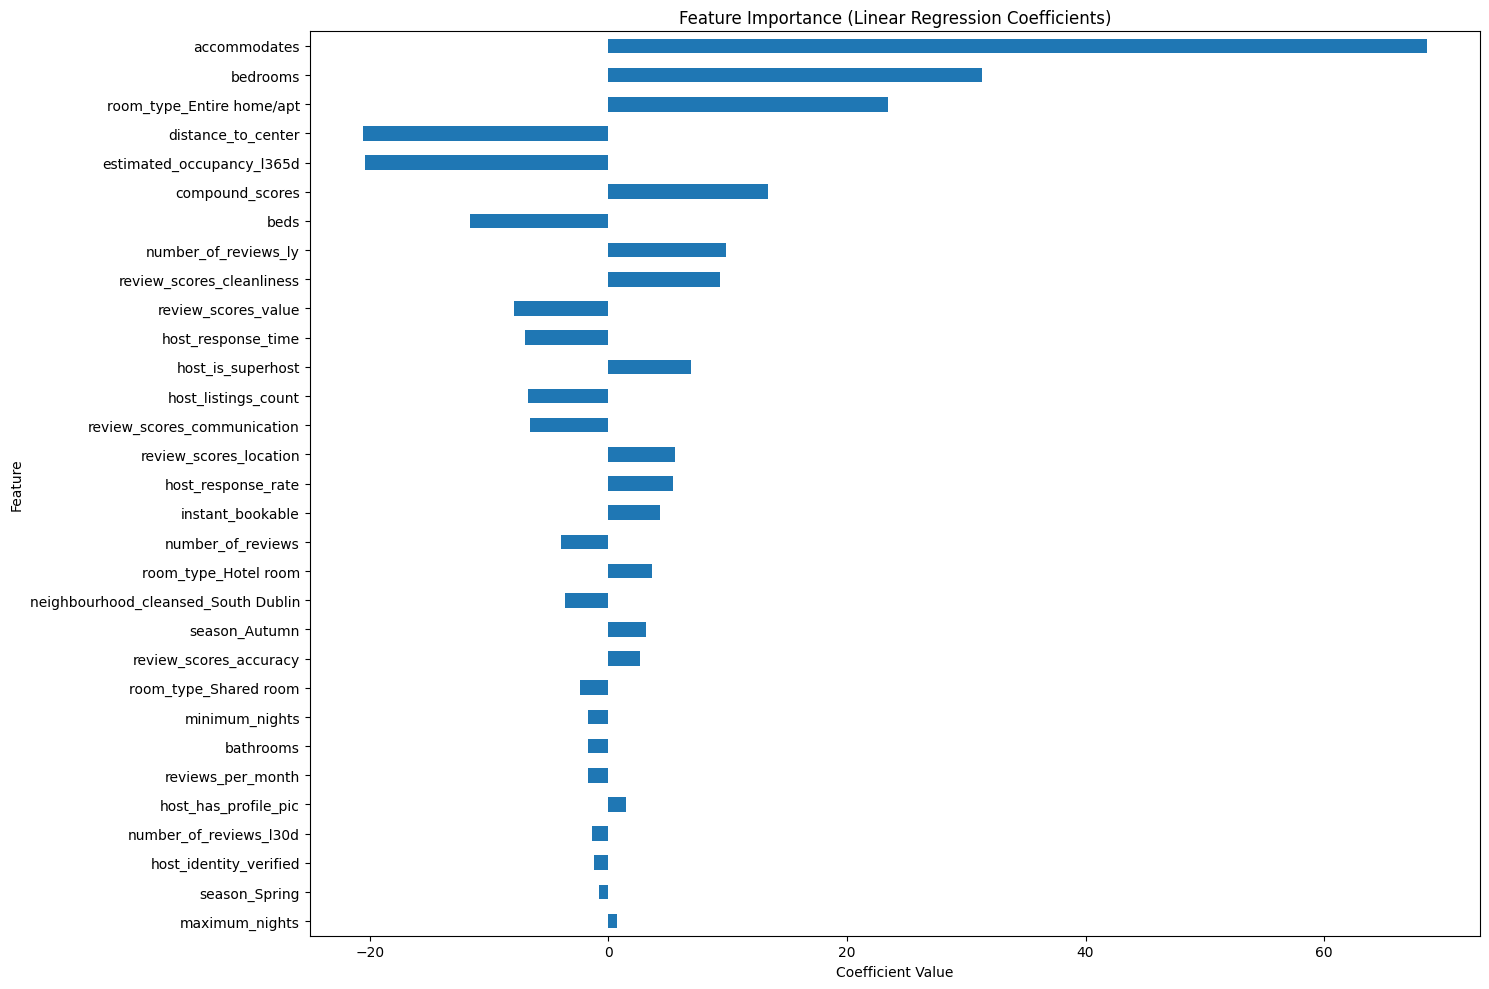

In [102]:
plt.figure(figsize=(15,10))
feature_importance.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


R²: 0.579
MAE: 55.85
RMSE: 90.87


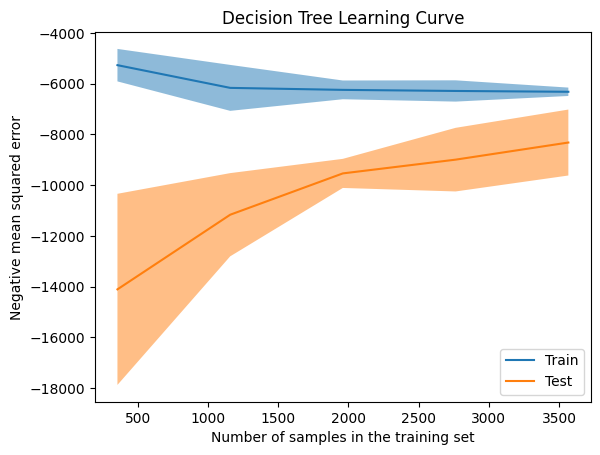

In [103]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Model
dt_model = DecisionTreeRegressor(max_depth = 5, random_state = 42)

# Train
dt_model.fit(X_train, y_train)

# Predict Price
y_pred = dt_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Learning Curve
LearningCurveDisplay.from_estimator(
    dt_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Decision Tree Learning Curve")
plt.show()


R²: 0.642
MAE: 51.81
RMSE: 83.72


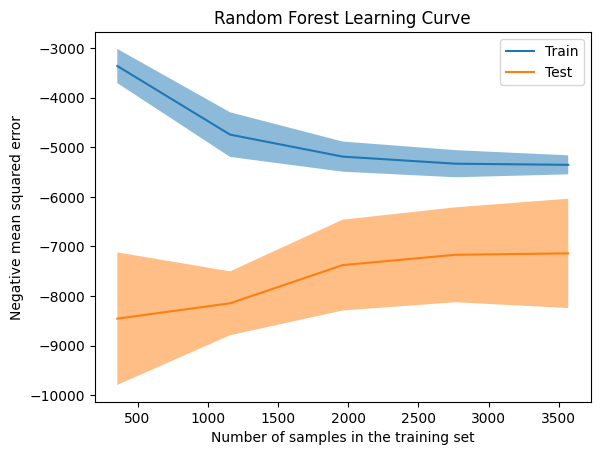

In [104]:
# Random Forest Model
rf_model = RandomForestRegressor(max_depth = 5, random_state = 42)

# Train
rf_model.fit(X_train, y_train)

# Predict Price
y_pred = rf_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Learning Curve
LearningCurveDisplay.from_estimator(
    rf_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Random Forest Learning Curve")
plt.show()

R2: 0.7324062938433273
MAE: 43.16673254645993
RMSE: 72.40615422885257


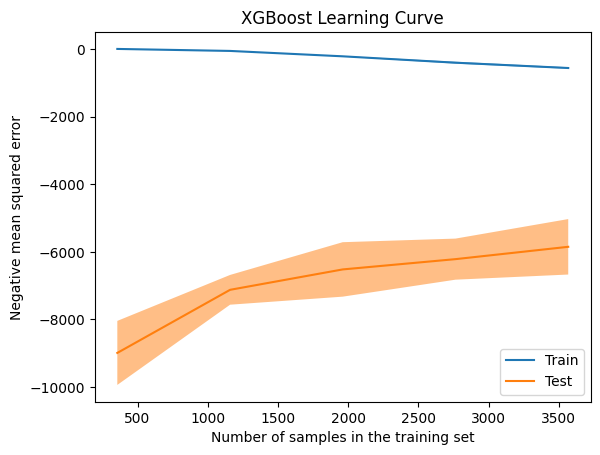

In [105]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Learning Curve
LearningCurveDisplay.from_estimator(
    xgb, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("XGBoost Learning Curve")
plt.show()


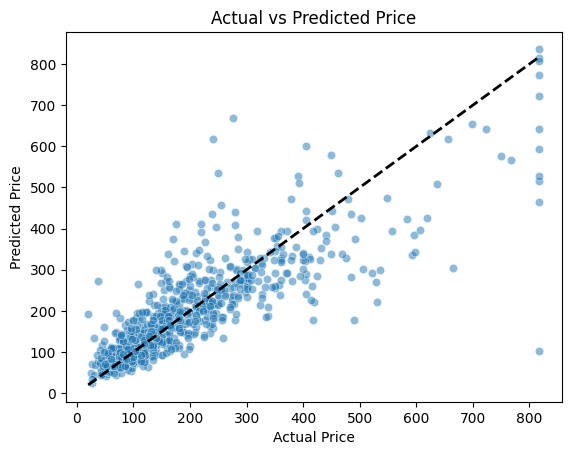

In [106]:
sns.scatterplot(x=y_test, y=y_pred, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

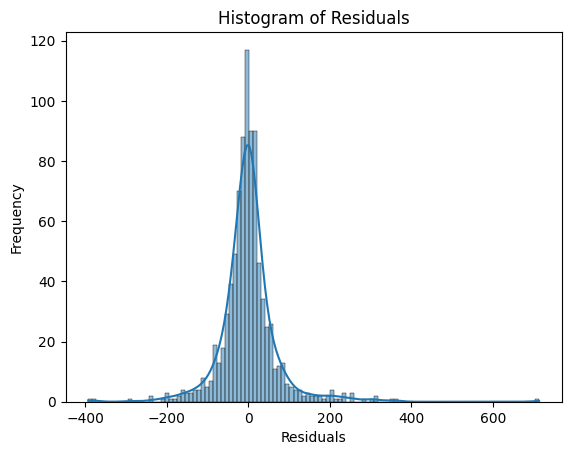

In [107]:
residuals = y_test - y_pred
residuals

sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

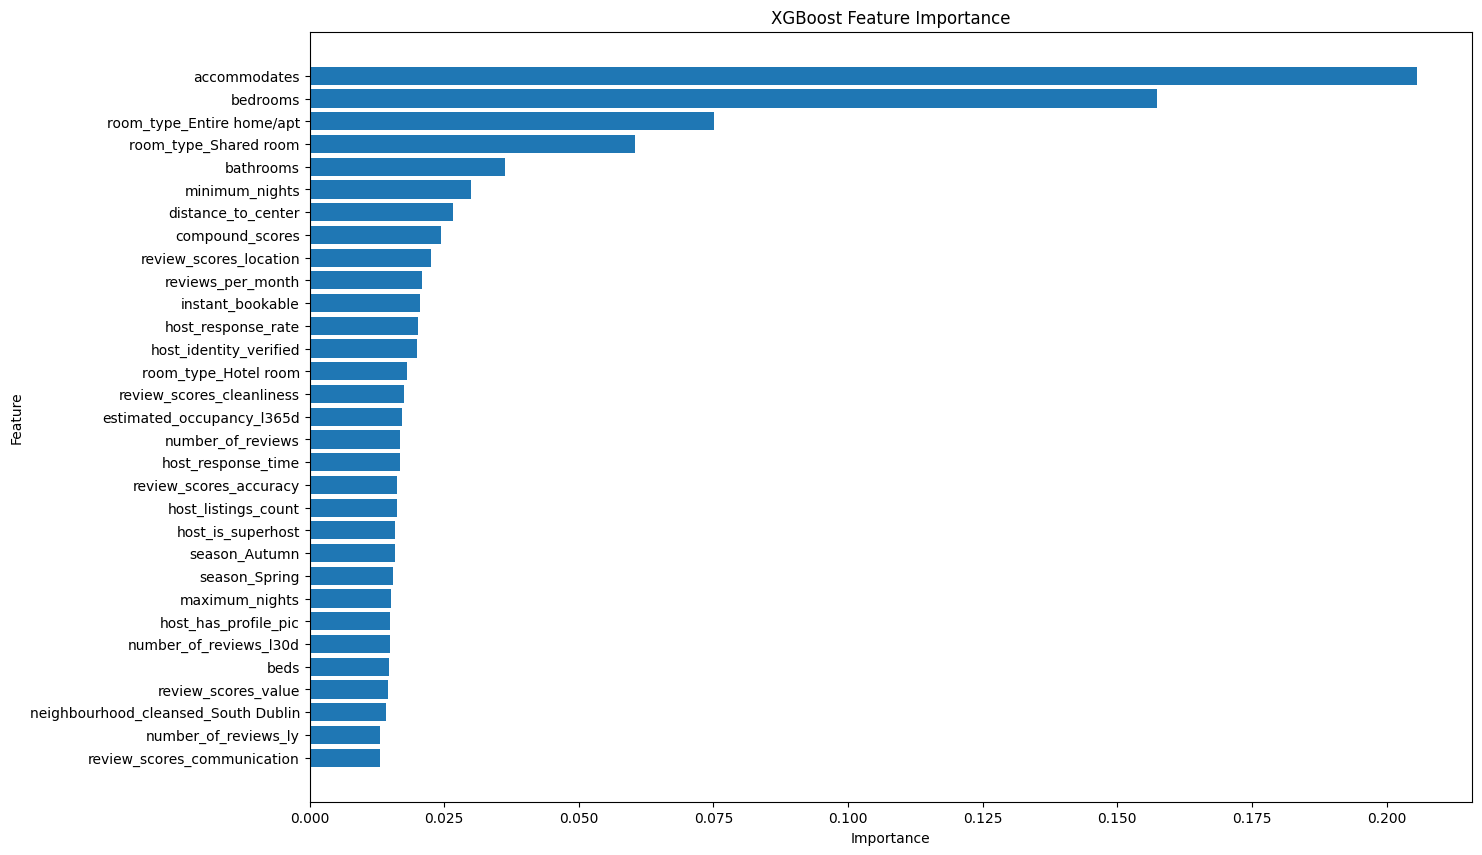

In [108]:
feature_names = X_train.columns

importance = xgb.feature_importances_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

fi

import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.barh(fi["feature"], fi["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [109]:
y_test

,price
297,326.0
2268,191.0
2413,303.0
3541,69.0
3915,81.0
...,...
4101,148.0
1616,200.0
1620,48.0
1634,328.0


**Log Price**

In [110]:
y = dublin_aggregated_df.loc[X_selected.index, 'price']

y_log = np.log1p(y)   # log(1 + price) → safe if any zero values


R2 (log): 0.6392909595575234
MAE (log): 0.28102902913123134
RMSE (log): 0.3978318416206361


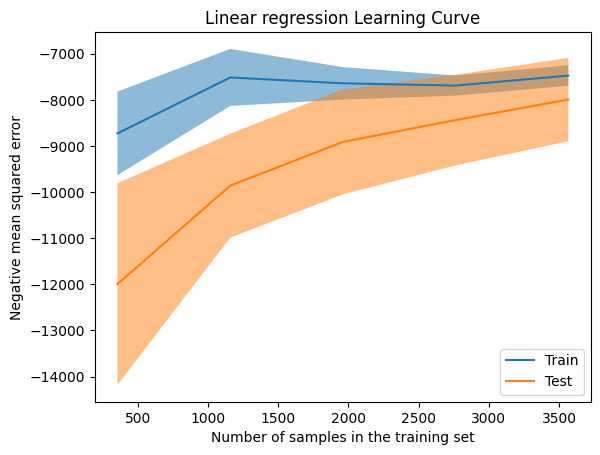

In [111]:
X = X_selected

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

pipe_lr_log = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr_log.fit(X_train, y_train)

y_pred_log = pipe_lr_log.predict(X_test)

print("R2 (log):", r2_score(y_test, y_pred_log))
print("MAE (log):", mean_absolute_error(y_test, y_pred_log))
print("RMSE (log):", np.sqrt(mean_squared_error(y_test, y_pred_log)))

# Learning Curve
LearningCurveDisplay.from_estimator(
    pipe_lr_log, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Linear regression Learning Curve")
plt.show()


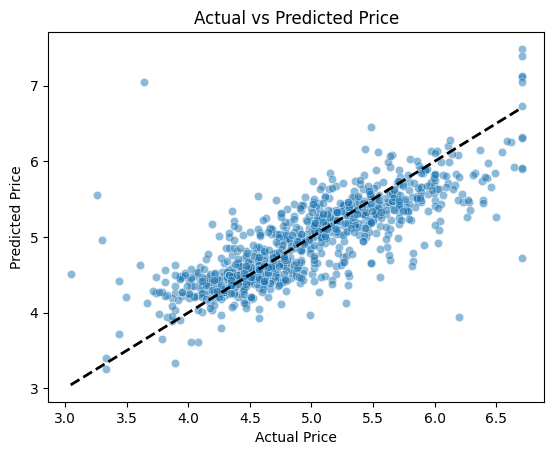

In [112]:
sns.scatterplot(x=y_test, y=y_pred_log, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [113]:
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test)

print("MAE (€):", mean_absolute_error(y_true_price, y_pred_price))
print("RMSE (€):", np.sqrt(mean_squared_error(y_true_price, y_pred_price)))


MAE (€): 54.53279749079459
RMSE (€): 104.73628162238082


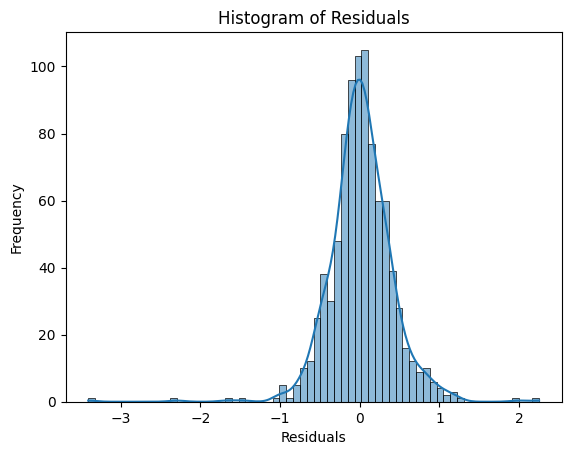

In [114]:
residuals = y_test - y_pred_log
residuals

sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


In [115]:
# Get coefficients from the trained model
coef = pipe_lr_log.named_steps['lr'].coef_

feature_importance = pd.Series(coef, index=X.columns)

# Sort by absolute importance
feature_importance = feature_importance.sort_values(key=np.abs, ascending=False)

feature_importance


,0
accommodates,0.297619
room_type_Entire home/apt,0.222868
distance_to_center,-0.114633
bedrooms,0.110828
estimated_occupancy_l365d,-0.101226
review_scores_cleanliness,0.068942
room_type_Shared room,-0.067343
review_scores_value,-0.060040
compound_scores,0.054028
number_of_reviews_ly,0.051082


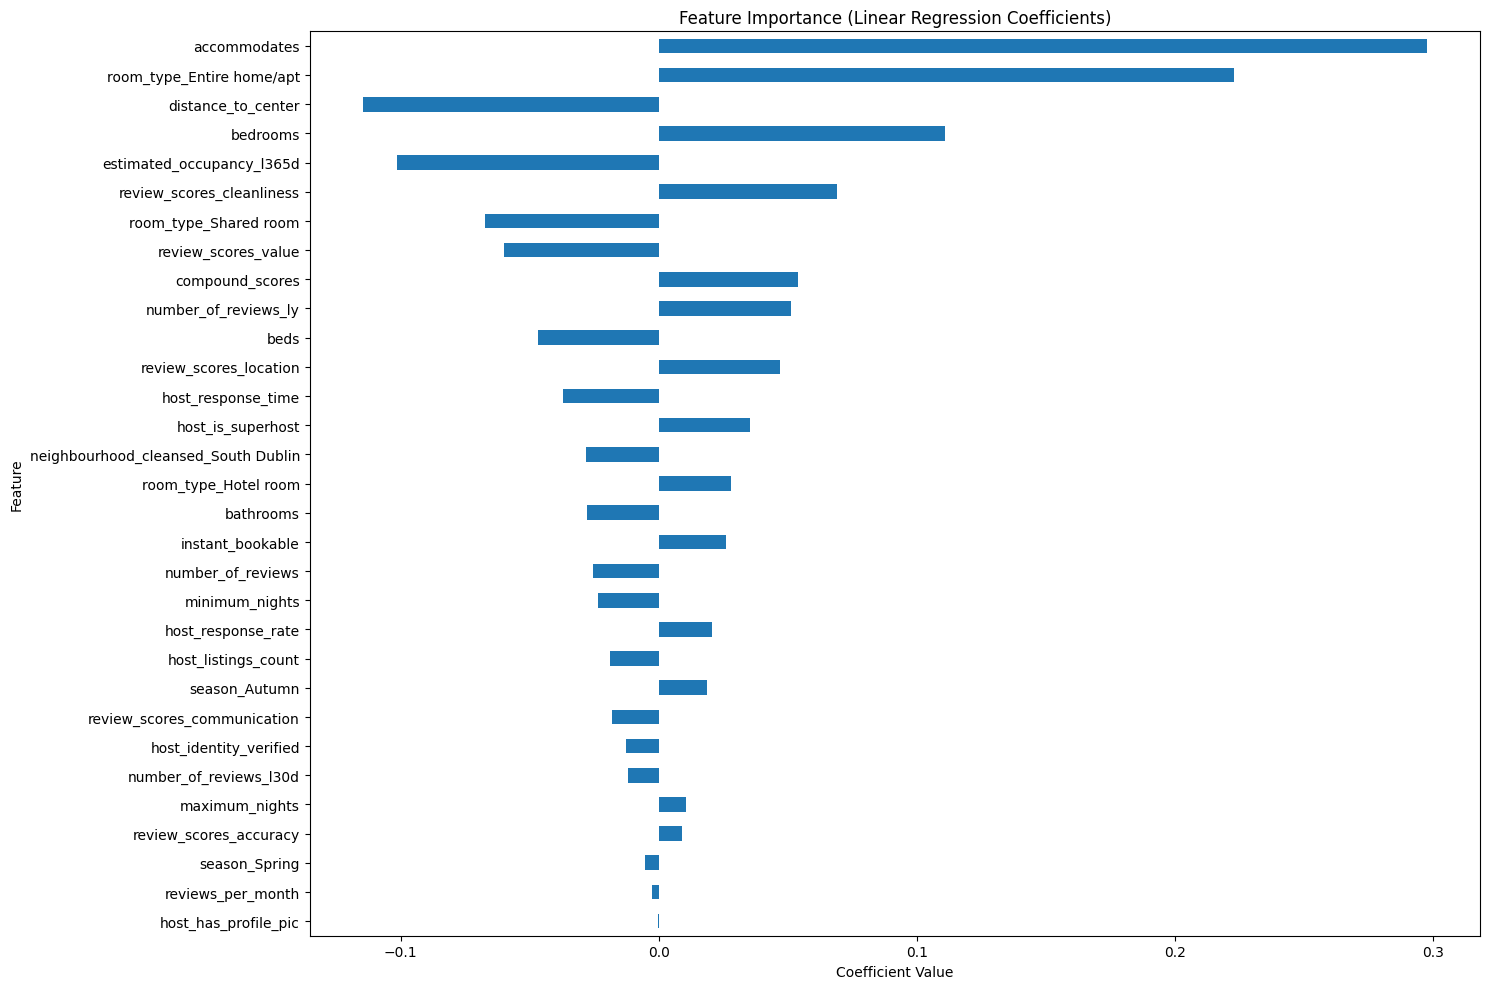

In [116]:
plt.figure(figsize=(15,10))
feature_importance.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

R²: -90990.152
MAE: 169.44
RMSE: 199.81


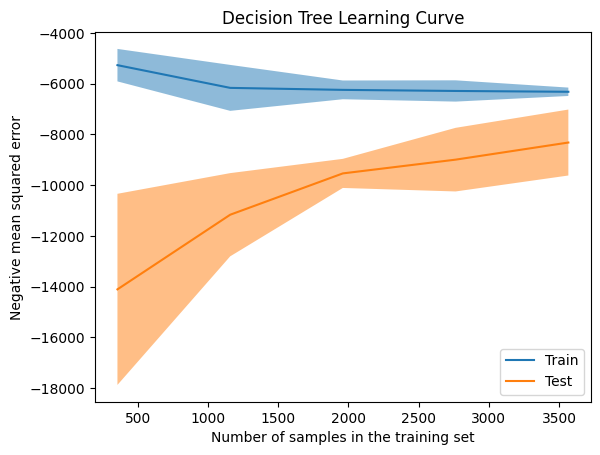

In [117]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Model
dt_model_log = DecisionTreeRegressor(max_depth = 5, random_state = 42)

# Train
dt_model_log.fit(X_train, y_train)

# Predict Price
y_pred_log = dt_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Learning Curve
LearningCurveDisplay.from_estimator(
    dt_model_log, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Decision Tree Learning Curve")
plt.show()


In [118]:
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test)

print("MAE (€):", mean_absolute_error(y_true_price, y_pred_price))
print("RMSE (€):", np.sqrt(mean_squared_error(y_true_price, y_pred_price)))

MAE (€): 1.058793206088824e+277
RMSE (€): inf


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


R²: 0.694
MAE: 0.276
RMSE: 0.366


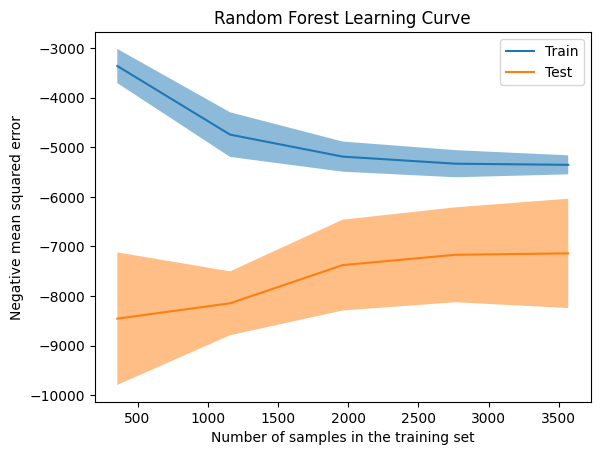

In [119]:
# Random Forest Model
rf_model_log = RandomForestRegressor(max_depth = 5, random_state = 42)

# Train
rf_model_log.fit(X_train, y_train)

# Predict Price
y_pred_log = rf_model_log.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# Learning Curve
LearningCurveDisplay.from_estimator(
    rf_model_log, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("Random Forest Learning Curve")
plt.show()

In [120]:
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test)

print("MAE (€):", mean_absolute_error(y_true_price, y_pred_price))
print("RMSE (€):", np.sqrt(mean_squared_error(y_true_price, y_pred_price)))

MAE (€): 52.56389059961694
RMSE (€): 90.40766915580572


R²: 0.780
MAE: 0.228
RMSE: 0.311


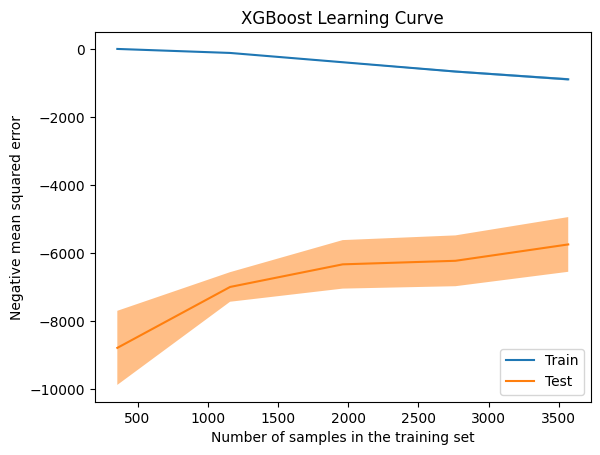

In [121]:
xgb_log = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_log.fit(X_train, y_train)

y_pred_log = xgb_log.predict(X_test)


r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# Learning Curve
LearningCurveDisplay.from_estimator(
    xgb_log, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='neg_mean_squared_error'
)
plt.title("XGBoost Learning Curve")
plt.show()


In [122]:
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test)

print("MAE (€):", mean_absolute_error(y_true_price, y_pred_price))
print("RMSE (€):", np.sqrt(mean_squared_error(y_true_price, y_pred_price)))

MAE (€): 42.252602472433594
RMSE (€): 71.03972436520944


"The XGBoost learning curve demonstrates healthy convergence. The steady improvement in the test score as we increase data volume, combined with the lack of a massive gap between training and testing performance, proves that the model is well-generalized. This confirms that the features we selected—including the sentiment scores—are providing consistent predictive power rather than causing the model to overfit to specific training examples."

In [123]:
import joblib

# Save the model
joblib.dump(xgb_log, "xgb_log_model.pkl")

# How to load it back later
loaded_xgb = joblib.load("xgb_log_model.pkl")


In [124]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

def learn_curves(pipe, X, y, cv=5):
    """
    Generates learning curves in log-scale MSE
    """
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, cv=cv, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Error')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation Error')
    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Squared Error (log-scale)')
    plt.title('Learning Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

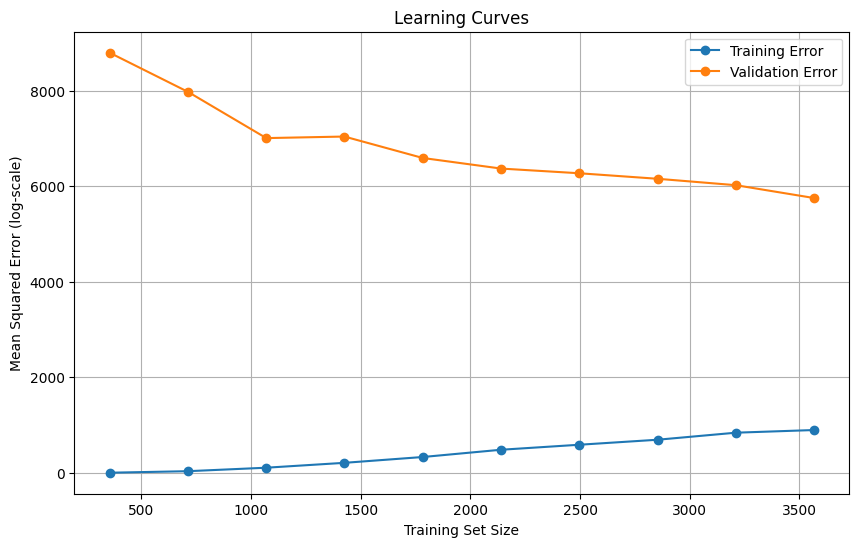

In [125]:
# Plot learning curves
learn_curves(xgb_log, X, y)

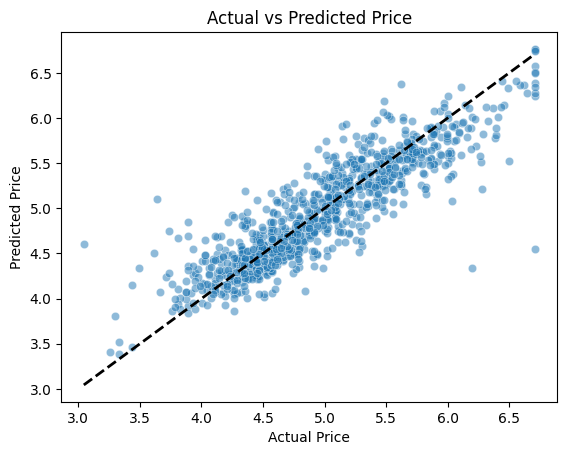

In [126]:
sns.scatterplot(x=y_test, y=y_pred_log, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

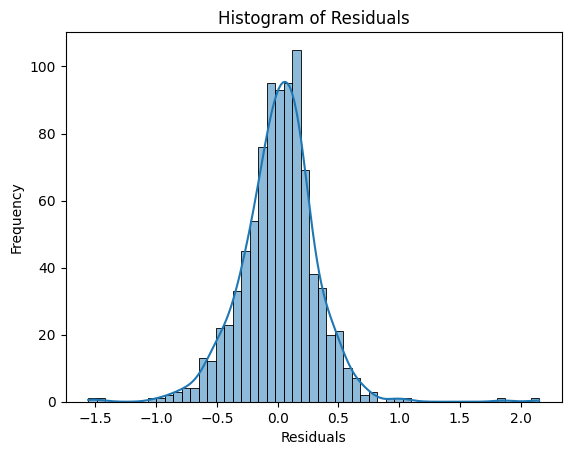

In [127]:
residuals = y_test - y_pred_log
residuals

sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


In [128]:
residuals = y_test - y_pred_log
residuals

,price
297,0.155171
2268,-0.172484
2413,0.220286
3541,-0.041149
3915,-0.438215
...,...
4101,-0.026757
1616,-0.240686
1620,-0.424036
1634,0.410200


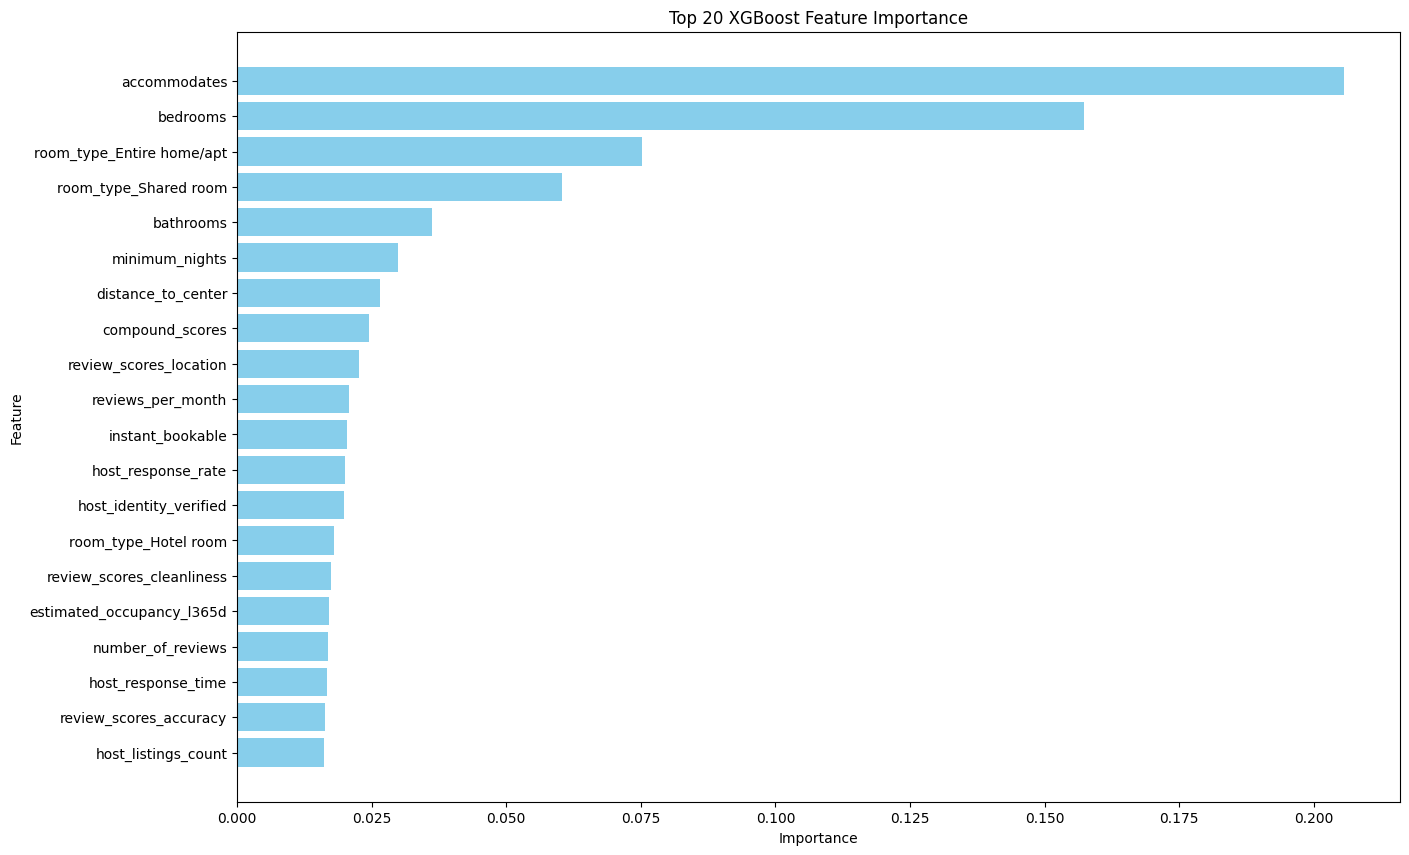

In [129]:
import matplotlib.pyplot as plt

# 1. Slice the DataFrame to the top 20
fi_top20 = fi.head(20)

# 2. Plot using the sliced data
plt.figure(figsize=(15, 10))
plt.barh(fi_top20["feature"], fi_top20["importance"], color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importance")

# Invert y-axis so the highest importance is at the top
plt.gca().invert_yaxis()
plt.show()


In [130]:
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def cross_validate_results(model, X_train, y_train, cv=5):
    """
    Performs cross-validation on training data and prints metrics.
    """
    # cross_val_predict generates 'out-of-fold' predictions
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)

    # Calculate metrics
    # Note: root_mean_squared_error(y_true, y_pred) is available in sklearn 1.4+
    # For older versions, we use np.sqrt(mean_squared_error)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred_cv))
    mae = mean_absolute_error(y_train, y_pred_cv)
    r2 = r2_score(y_train, y_pred_cv)

    print(f"--- {cv}-Fold Cross-Validation Results ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print("-" * 10)

# Correct usage: Use your TRAINING data here
cross_validate_results(xgb_log, X_train, y_train, cv=5)


--- 5-Fold Cross-Validation Results ---
RMSE: 0.2993
MAE:  0.2193
R²:   0.7948
----------


In [131]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Define the parameter space
# We focus on depth and learning rate to control complexity
param_distributions = {
    'n_estimators': [400, 600, 800],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1],    # L1 regularization
    'reg_lambda': [1, 2, 5],     # L2 regularization
    'gamma': [0, 0.1, 0.2]       # Minimum loss reduction to split
}

# 2. Initialize the model
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 3. Setup the Randomized Search
# n_iter=20 will try 20 different random combinations
random_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# 4. Fit the search (Ensure you use your log-transformed y_train)
random_search.fit(X_train, y_train)

# 5. Extract the best model
best_xgb = random_search.best_estimator_

# 6. Evaluate
y_pred_log = best_xgb.predict(X_test)

print("--- Tuned XGBoost Results ---")
print("Best Params:", random_search.best_params_)
print("R2 (log):", r2_score(y_test, y_pred_log))
print("MAE (log):", mean_absolute_error(y_test, y_pred_log))
print("RMSE (log):", np.sqrt(mean_squared_error(y_test, y_pred_log)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
--- Tuned XGBoost Results ---
Best Params: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.9}
R2 (log): 0.7757539129530211
MAE (log): 0.23302699822635212
RMSE (log): 0.3136775689228015


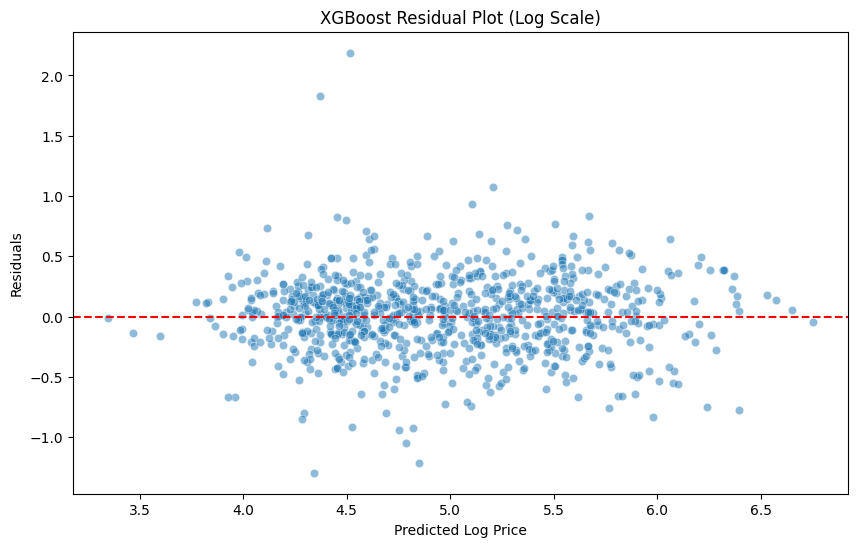

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get predictions (on the log scale)
y_pred_log = best_xgb.predict(X_test)

# 2. Calculate Residuals
# Residual = Actual - Predicted
residuals = y_test - y_pred_log

# 3. Create the Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('XGBoost Residual Plot (Log Scale)')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residuals')
plt.show()

In [ ]:
'''
sns.pairplot(
    selected_features,
    kind="reg",
    plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.4}}
)
plt.suptitle('Pairplot with Regression Lines', y=1.02)
plt.show()
'''

'\nsns.pairplot(\n    selected_features,\n    kind="reg",\n    plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.4}}\n)\nplt.suptitle(\'Pairplot with Regression Lines\', y=1.02)\nplt.show()\n'

**Select best predictors**

**Modelling**

Multiple linear regression model was set as the baseline model in order to see how well the model performs with other complex model and it is also used for interpretation.

The preferred model was selected based on:

(a) Highest mean R², lowest MAE and RMSE;

(b) Interpretability of feature effects

the remaining unexplained variation in the price to data that is not present, such as picture quality e.tc.

**XGBoost Hyper Parameter tuning**

Hyperparameter tuning was performed using RandomizedSearchCV, which randomly samples parameter combinations from a predefined search space, providing a more computationally efficient alternative to grid search while achieving comparable optimisation performance (Bergstra and Bengio, 2012). The parameters tuned included n_estimators, max_depth, and learning_rate, which influence model complexity and learning dynamics.

Three-fold cross-validation was applied to reduce variance in performance estimates and improve generalisability. Model performance was evaluated using the root mean squared error (RMSE), which penalises large errors and is appropriate for regression tasks (Hastie, Tibshirani and Friedman, 2009). The optimal model configuration was selected and used for subsequent analysis.

In [133]:
dublin_merged_df.to_csv("dublin_merged_df.csv", index=False)


In [186]:
dublin_aggregated_df.to_csv("dublin_aggregated_df.csv", index=False)

In [134]:
dublin_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275369 entries, 0 to 310099
Data columns (total 64 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   id_x                                          275369 non-null  int64         
 1   listing_url                                   275369 non-null  object        
 2   description                                   275369 non-null  object        
 3   picture_url                                   275369 non-null  object        
 4   host_since                                    275369 non-null  datetime64[ns]
 5   host_response_time                            275369 non-null  int64         
 6   host_response_rate                            275369 non-null  float64       
 7   host_acceptance_rate                          275369 non-null  float64       
 8   host_is_superhost                             275369 non-nu

In [135]:
dublin_merged_df.to_csv("dublin_merged_df.csv.gz", index=False, compression="gzip")


In [ ]:
#recommender_df = dublin_merged_df[['reviewer_id','id_x','description','compound_scores','price']]
#recommender_df.to_csv("recommender_data.csv.gz", index=False, compression="gzip")


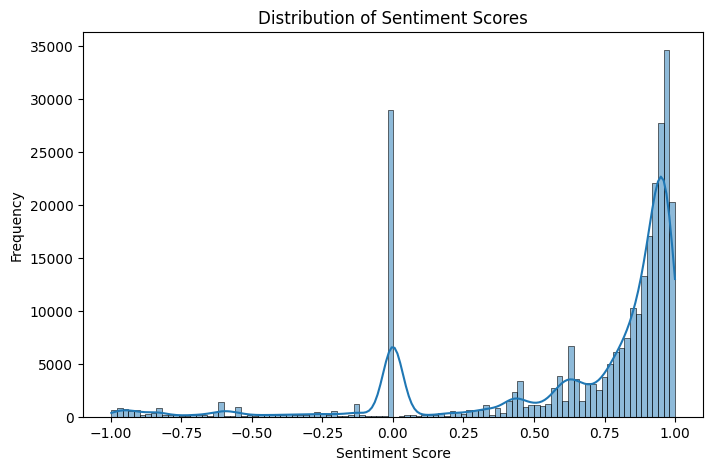

In [136]:
# check the distribution of sentiment scores
plt.figure(figsize=(8, 5))
sns.histplot(dublin_merged_df['compound_scores'], bins=100, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
'''
# Clip the Negative Outliers ---
# Since my data is mostly 0.75 to 1.0, a -1.0 is an extreme outlier.
# I will "clip" the bottom at -0.5.
# This keeps the 'bad' signal but reduces its mathematical weight.
dublin_merged_df['compound_scores'] = dublin_merged_df['compound_scores'].clip(lower=-0.5, upper=1.0)
'''


'\n# Clip the Negative Outliers ---\n# Since my data is mostly 0.75 to 1.0, a -1.0 is an extreme outlier.\n# I will "clip" the bottom at -0.5.\n# This keeps the \'bad\' signal but reduces its mathematical weight.\ndublin_merged_df[\'compound_scores\'] = dublin_merged_df[\'compound_scores\'].clip(lower=-0.5, upper=1.0)\n'

**Prepare the data (User–Item–Rating matrix)**

In [170]:
from surprise import Reader, SVD, Dataset, accuracy, BaselineOnly, SlopeOne
from surprise.model_selection import GridSearchCV, train_test_split, cross_validate
from surprise.model_selection import train_test_split


In [172]:
# Keep only required columns
ratings_df = dublin_merged_df[
    ['reviewer_id', 'id_x', 'price', 'description', 'accommodates', 'beds', 'bedrooms', 'bathrooms', 'picture_url', 'listing_url', 'compound_scores']
].dropna()


**Define Surprise reader (VADER scale)**

In [173]:
reader = Reader(rating_scale=(-1, 1))
data = Dataset.load_from_df(
    ratings_df[['reviewer_id', 'id_x', 'compound_scores']],
    reader
)


In [174]:
ratings_df.head(1)

,reviewer_id,id_x,price,description,accommodates,beds,bedrooms,bathrooms,picture_url,listing_url,compound_scores
0,393348,44077,76.0,Our house is a cosy comfortable cottage with ...,2,2.0,1.0,1.0,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9612


**Proper Surprise train/test split**

In [175]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)


In [176]:
testset

[(506440060, 27804202, 0.6908),
 (115028398, 24474346, 0.9732),
 (15547725, 22717614, 0.7351),
 (126175128, 26634024, 0.8622),
 (212459030, 946346290370998800, -0.8316),
 (229161012, 51327861, 0.9677),
 (229119012, 725270051563994871, 0.8729),
 (596009676, 1189992796212453008, 0.4926),
 (60993499, 41452325, 0.8268),
 (489235152, 762773628022958892, 0.7717),
 (464119949, 881993203074329547, 0.4019),
 (355632805, 17688731, 0.6369),
 (61499860, 815840151153375623, 0.9758),
 (6077525, 23751430, 0.0),
 (39236304, 49235778, 0.9563),
 (171566816, 1076736781464976333, 0.9661),
 (8787890, 23070253, 0.9827),
 (232841040, 4177992, 0.987),
 (453191418, 1230600060472983331, 0.8516),
 (28737103, 2489550, 0.8795),
 (118024735, 12643250, 0.9607),
 (39937050, 49856320, 0.9741),
 (28863240, 52672187, 0.2732),
 (179506373, 18904305, 0.836),
 (15002340, 7132062, 0.8316),
 (564324711, 647206437611440264, 0.9516),
 (160754907, 15831512, 0.8858),
 (25553754, 38034541, 0.9761),
 (343752112, 16355072, 0.9552),

In [177]:
ratings_df

,reviewer_id,id_x,price,description,accommodates,beds,bedrooms,bathrooms,picture_url,listing_url,compound_scores
0,393348,44077,76.0,Our house is a cosy comfortable cottage with ...,2,2.0,1.0,1.0,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9612
1,444004,44077,76.0,Our house is a cosy comfortable cottage with ...,2,2.0,1.0,1.0,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9838
2,465058,44077,76.0,Our house is a cosy comfortable cottage with ...,2,2.0,1.0,1.0,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9831
3,490005,44077,76.0,Our house is a cosy comfortable cottage with ...,2,2.0,1.0,1.0,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9501
4,520460,44077,76.0,Our house is a cosy comfortable cottage with ...,2,2.0,1.0,1.0,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9835
...,...,...,...,...,...,...,...,...,...,...,...
310095,28868272,1435562101631876205,211.0,indeed this is a stylish place to stay it's pe...,7,6.0,3.0,3.0,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/rooms/1435562101631876205,0.8979
310096,495710532,1435808782560354383,100.0,The whole group will enjoy easy access to ever...,2,1.0,1.0,1.0,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/rooms/1435808782560354383,0.8898
310097,58079970,1436309939770705037,71.0,Enjoy a peaceful stay at this centrally locate...,2,1.0,1.0,0.5,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/rooms/1436309939770705037,0.2732
310098,658875330,1436361984511859598,60.0,A double room is available in the Lucan area i...,2,1.0,1.0,1.0,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/rooms/1436361984511859598,0.9767


In [178]:
# 1. Convert the list of tuples into a Pandas DataFrame
# The Surprise testset structure is typically (user_id, item_id, actual_rating)
df_test = pd.DataFrame(testset, columns=['user_id', 'item_id', 'actual_rating'])

# 2. Now you can save it to a CSV
df_test.to_csv('rec_test_data.csv', index=False)

print("File 'rec_test_data.csv' has been saved successfully.")


File 'rec_test_data.csv' has been saved successfully.


In [179]:
# Initialize and cross-validate BaselineOnly model
baseline_model = BaselineOnly()
cv_baseline = cross_validate(baseline_model, data, cv=5, verbose=True)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating RMSE, MAE of algorithm BaselineOnly on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4207  0.4191  0.4171  0.4122  0.4178  0.4174  0.0029  
MAE (testset)     0.3064  0.3058  0.3047  0.3018  0.3045  0.3046  0.0016  
Fit time          2.62    2.76    3.65    2.91    2.95    2.98    0.35    
Test time         0.30    0.29    0.43    0.26    0.41    0.34    0.07    


In [180]:
import joblib

# 1. Build the full trainset
full_trainset = data.build_full_trainset()

# 2. Fit the baseline model on the entire dataset
baseline_model = BaselineOnly()
baseline_model.fit(full_trainset)

# 3. Save using joblib with your requested filename
joblib.dump(baseline_model, 'baseline_model_joblib.pkl')

print("Model saved successfully as baseline_model_joblib.pkl")


Estimating biases using als...
Model saved successfully as baseline_model_joblib.pkl


In [181]:
slope_one = SlopeOne()
cv_slopeone = cross_validate(slope_one, data, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4281  0.4259  0.4277  0.4289  0.4264  0.4274  0.0011  
MAE (testset)     0.3131  0.3120  0.3140  0.3142  0.3133  0.3133  0.0008  
Fit time          2.83    2.43    2.44    5.23    2.52    3.09    1.08    
Test time         2.28    0.48    1.57    0.54    1.60    1.30    0.69    


**Create SVD Model Object**

In [182]:
svd_model = SVD()
cv_svd_model = cross_validate(svd_model, data, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4165  0.4159  0.4204  0.4189  0.4168  0.4177  0.0017  
MAE (testset)     0.3039  0.3037  0.3058  0.3050  0.3045  0.3046  0.0007  
Fit time          7.70    6.55    7.52    8.81    8.43    7.80    0.78    
Test time         0.32    0.49    0.32    0.31    0.56    0.40    0.11    


In [183]:
ratings_df.to_csv("rating_data.csv.gz", index=False, compression="gzip")

In [184]:
import joblib

# Note: cross_validate evaluates the model but doesn't leave svd_model 'trained' on a full dataset.
# Train on your full trainset before saving:
trainset = data.build_full_trainset()
svd_model.fit(trainset)

# Save the model
joblib.dump(svd_model, "svd_model_joblib.pkl")

# How to load it back later
loaded_svd = joblib.load("svd_model_joblib.pkl")


In [185]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275369 entries, 0 to 310099
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   reviewer_id      275369 non-null  int64  
 1   id_x             275369 non-null  int64  
 2   price            275369 non-null  float64
 3   description      275369 non-null  object 
 4   accommodates     275369 non-null  int64  
 5   beds             275369 non-null  float64
 6   bedrooms         275369 non-null  float64
 7   bathrooms        275369 non-null  float64
 8   picture_url      275369 non-null  object 
 9   listing_url      275369 non-null  object 
 10  compound_scores  275369 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 25.2+ MB


In [149]:
import pandas as pd

# Define the bin edges
# We use -1.1 and 1.1 to ensure the exact values of -1.0 and 1.0 are included
bins = [-1.1, -0.5, 0.05, 0.5, 0.9, 1.1]

# Define the labels for each bin
labels = [
    '1 (Critical failure)',
    '2 (Disappointing)',
    '3 (Average/Polite)',
    '4 (Standard Good Stay)',
    '5 (Exceptionally Good)'
]

# Create the new column
ratings_df['rating_label'] = pd.cut(ratings_df['compound_scores'], bins=bins, labels=labels)

# If you want just the numeric rating (1-5) as an integer:
ratings_df['rating_score'] = pd.cut(ratings_df['compound_scores'], bins=bins, labels=[1, 2, 3, 4, 5]).astype(int)

# Check the distribution of your new ratings
print(ratings_df['rating_label'].value_counts().sort_index())


rating_label
1 (Critical failure)        9558
2 (Disappointing)          34286
3 (Average/Polite)         16017
4 (Standard Good Stay)     94785
5 (Exceptionally Good)    120723
Name: count, dtype: int64


In [150]:
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, SVD, SlopeOne, BaselineOnly
from surprise.model_selection import cross_validate

# 1. Setup the data
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_df[['reviewer_id', 'id_x', 'rating_score']], reader)

# 2. Define the models with verbose=False to stop the "Estimating biases" spam
models = [
    BaselineOnly(bsl_options={'method': 'als', 'n_epochs': 5}, verbose=False),
    SlopeOne(),
    SVD()
]

results = []

for model in models:
    print(f"Running {model.__class__.__name__}...")
    # Using 3-fold CV to save time on 275k rows
    cv_results = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=3, verbose=False)

    # Use np.mean() instead of .mean() to avoid the AttributeError
    results.append({
        'Model': model.__class__.__name__,
        'RMSE': np.mean(cv_results['test_rmse']),
        'MAE': np.mean(cv_results['test_mae']),
        'Fit Time (s)': np.mean(cv_results['fit_time'])
    })

# 3. Display the comparison table
results_df = pd.DataFrame(results)
print("\n--- Model Comparison ---")
print(results_df.sort_values(by='RMSE'))


Running BaselineOnly...
Running SlopeOne...
Running SVD...

--- Model Comparison ---
          Model      RMSE       MAE  Fit Time (s)
2           SVD  1.099951  0.858118      5.525071
0  BaselineOnly  1.100306  0.856927      1.276146
1      SlopeOne  1.137327  0.840356      2.305661


In [ ]:
from surprise import BaselineOnly, Dataset, Reader

# 1. Prepare the model
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_df[['reviewer_id', 'id_x', 'rating_score']], reader)
full_trainset = data.build_full_trainset()

# 2. Train using ALS (Alternating Least Squares)
# We use ALS because it's robust for this kind of bias estimation
bsl_options = {'method': 'als', 'n_epochs': 5}
algo = BaselineOnly(bsl_options=bsl_options)
algo.fit(full_trainset)

# 3. Quick Prediction Function
def get_baseline_recommendations(user_id, n=5):
    all_ids = ratings_df['id_x'].unique()
    # Predict for all items
    predictions = [algo.predict(user_id, iid) for iid in all_ids]
    # Sort by the estimated rating
    predictions.sort(key=lambda x: x.est, reverse=True)

    top_n_ids = [p.iid for p in predictions[:n]]
    return ratings_df[ratings_df['id_x'].isin(top_n_ids)][['id_x', 'price', 'description']].drop_duplicates('id_x')

# Test it
user_to_check = ratings_df['reviewer_id'].iloc[0]
print(f"Baseline Recommendations for User {user_to_check}:")
print(get_baseline_recommendations(user_to_check))


Estimating biases using als...
Baseline Recommendations for User 393348:
            id_x  price                                        description
2438      292757  130.0  The following is what past guests have said th...
25365    4067786  200.0  The 5* Reviews of our past guests say it all. ...
39170    6674154  349.0  Beautiful newly renovated red brick period hou...
42535    7071476  154.0  Renovated 19th-century artisan cottage by the ...
185676  45009041  191.0  Beautifully private apartment situated on top ...


In [ ]:
algo = BaselineOnly()
algo.fit(trainset)  # This creates the 'trainset' attribute

# 3. Now you can predict
algo.predict(444004, 44077, verbose=True)

Estimating biases using als...
user: 444004     item: 44077      r_ui = None   est = 4.19   {'was_impossible': False}


Prediction(uid=444004, iid=44077, r_ui=None, est=4.185878979394468, details={'was_impossible': False})

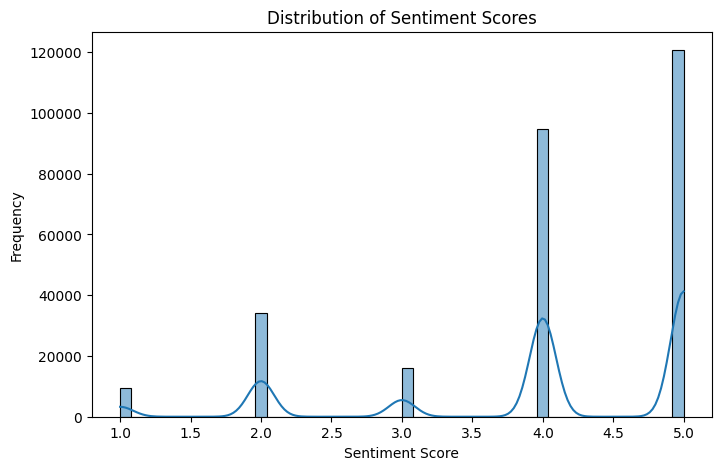

In [ ]:
# check the distribution of sentiment scores
plt.figure(figsize=(8, 5))
sns.histplot(ratings_df['rating_score'], bins=50, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Check the distribution of your new ratings
print(ratings_df['rating_score'].value_counts().sort_index())

rating_score
1      9558
2     34286
3     16017
4     94785
5    120723
Name: count, dtype: int64


In [ ]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275369 entries, 0 to 310099
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   reviewer_id      275369 non-null  int64   
 1   id_x             275369 non-null  int64   
 2   price            275369 non-null  float64 
 3   description      275369 non-null  object  
 4   picture_url      275369 non-null  object  
 5   listing_url      275369 non-null  object  
 6   compound_scores  275369 non-null  float64 
 7   rating_label     275369 non-null  category
 8   rating_score     275369 non-null  int64   
dtypes: category(1), float64(2), int64(3), object(3)
memory usage: 19.2+ MB


In [ ]:
'''
from scipy.sparse import csr_matrix
ratings_df = pd.DataFrame(dublin_merged_df)

# 2. Define the Binning Logic
def map_vader_to_rating(score):
    if score >= 0.9:
        return 5  # Exceptional
    elif score >= 0.5:
        return 4  # Good
    elif score >= 0.05:
        return 3  # Positive/Ok
    elif score >= -0.5:
        return 2  # Disappointing / Neutral spike
    else:
        return 1  # Very Bad

# 3. Apply the mapping
ratings_df['derived_rating'] = ratings_df['compound_scores'].apply(map_vader_to_rating)

# 4. Create the Rating Matrix (Pivot Table)
# Note: We fill NaN with 0 because a 0 indicates "No Review"
rating_matrix_df = ratings_df.pivot_table(index='reviewer_id', columns='id_x', values='derived_rating').fillna(0)

# 5. Convert to Sparse Matrix for Memory Efficiency
# This is what most recommendation models (SVD, ALS) actually take as input
sparse_rating_matrix = csr_matrix(rating_matrix_df.values)

print("Mapped Dataframe:")
print(ratings_df[['compound_scores', 'derived_rating']])
print("\nSparse Matrix Shape:", sparse_rating_matrix.shape)
'''

In [ ]:
'''
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(1, 5))
# Reshape is needed because the scaler expects a 2D array
ratings_df['rating_scale'] = scaler.fit_transform(ratings_df[['compound_scores']])
'''

In [ ]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(
    ratings_df[['reviewer_id', 'id_x', 'rating_score']],
    reader
)

In [ ]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Initialize and cross-validate BaselineOnly model
baseline_model = BaselineOnly()
cv_baseline = cross_validate(baseline_model, data, cv=5, verbose=True)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating RMSE, MAE of algorithm BaselineOnly on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.1028  1.0939  1.0992  1.0980  1.0990  1.0986  0.0028  
MAE (testset)     0.8576  0.8532  0.8570  0.8545  0.8576  0.8560  0.0018  
Fit time          2.12    1.96    2.56    2.00    2.21    2.17    0.22    
Test time         0.22    0.23    1.10    0.79    0.24    0.52    0.36    


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

ratings_df['compound_scores_z'] = scaler.fit_transform(
    ratings_df[['compound_scores']]
)

In [ ]:
from surprise import Dataset, Reader

reader = Reader(
    rating_scale=(
        ratings_df['compound_scores_z'].min(),
        ratings_df['compound_scores_z'].max()
    )
)

data = Dataset.load_from_df(
    ratings_df[['reviewer_id', 'id_x', 'compound_scores_z']],
    reader
)


In [ ]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Initialize and cross-validate BaselineOnly model
baseline_model = BaselineOnly()
cv_baseline = cross_validate(baseline_model, data, cv=5, verbose=True)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating RMSE, MAE of algorithm BaselineOnly on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9659  0.9615  0.9662  0.9772  0.9640  0.9670  0.0054  
MAE (testset)     0.7037  0.7029  0.7060  0.7122  0.7040  0.7058  0.0034  
Fit time          2.53    2.24    1.77    1.67    2.05    2.05    0.31    
Test time         0.92    0.84    0.26    0.26    0.43    0.54    0.29    


In [ ]:
slope_one = SlopeOne()
cv_slopeone = cross_validate(slope_one, data, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9950  0.9940  0.9879  0.9945  0.9826  0.9908  0.0048  
MAE (testset)     0.7287  0.7292  0.7252  0.7264  0.7227  0.7264  0.0024  
Fit time          5.67    2.33    2.33    3.52    2.31    3.23    1.31    
Test time         1.21    0.46    0.47    0.48    1.04    0.73    0.33    


In [ ]:
svd_model = SVD()
cv_svd_model = cross_validate(svd_model, data, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9622  0.9620  0.9654  0.9697  0.9719  0.9662  0.0040  
MAE (testset)     0.7015  0.7026  0.7050  0.7065  0.7062  0.7043  0.0020  
Fit time          9.28    6.22    7.16    5.79    7.17    7.12    1.20    
Test time         1.08    0.30    0.30    0.32    0.30    0.46    0.31    


**Training Model**

In [ ]:
svd_model.fit(trainset)

**Making Predictions and Calculating Errors**

In [ ]:
predictions = svd_model.test(testset)

In [ ]:
accuracy.rmse(predictions)

RMSE: 0.4184


0.4184302408145895

In [ ]:
svd_model.predict(393348, 44077, verbose=True)

user: 393348     item: 44077      r_ui = None   est = 0.77   {'was_impossible': False}


Prediction(uid=393348, iid=44077, r_ui=None, est=0.7706669612822087, details={'was_impossible': False})

In [ ]:
svd_model.predict(444004, 44077, verbose=True)

user: 444004     item: 44077      r_ui = None   est = 0.75   {'was_impossible': False}


Prediction(uid=444004, iid=44077, r_ui=None, est=0.7480389659494213, details={'was_impossible': False})

In [ ]:
ratings_df[ratings_df["reviewer_id"] == 393348]

,reviewer_id,id_x,price,description,picture_url,listing_url,compound_scores
0,393348,44077,76.0,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9612


**Hyperparameter tuning**

In [ ]:
from surprise import SVD
from surprise.model_selection import GridSearchCV


In [ ]:
param_grid = {
    'n_factors': [20, 50, 100],
    'n_epochs': [10, 20],
    'reg_all': [0.02, 0.05, 0.1],
    'lr_all': [0.002, 0.005]
}

gs = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse'],
    cv=5,
    n_jobs=-1
)

gs.fit(data)

best_svd = gs.best_estimator['rmse']
trainset = data.build_full_trainset()
best_svd.fit(trainset)

best_svd.predict(393348, 44077, verbose=True)



user: 393348     item: 44077      r_ui = None   est = 0.67   {'was_impossible': False}


Prediction(uid=393348, iid=44077, r_ui=None, est=0.6661923558718358, details={'was_impossible': False})

In [ ]:
print("Best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])


Best RMSE: 0.41702146390821665
Best params: {'n_factors': 20, 'n_epochs': 20, 'reg_all': 0.1, 'lr_all': 0.005}


In [ ]:
# Example: predictions from test set
predictions = best_svd.test(testset)

# Convert predictions to a DataFrame
pred_df = pd.DataFrame([{
    'user': pred.uid,
    'item': pred.iid,
    'true_rating': pred.r_ui,
    'pred_rating': pred.est
} for pred in predictions])


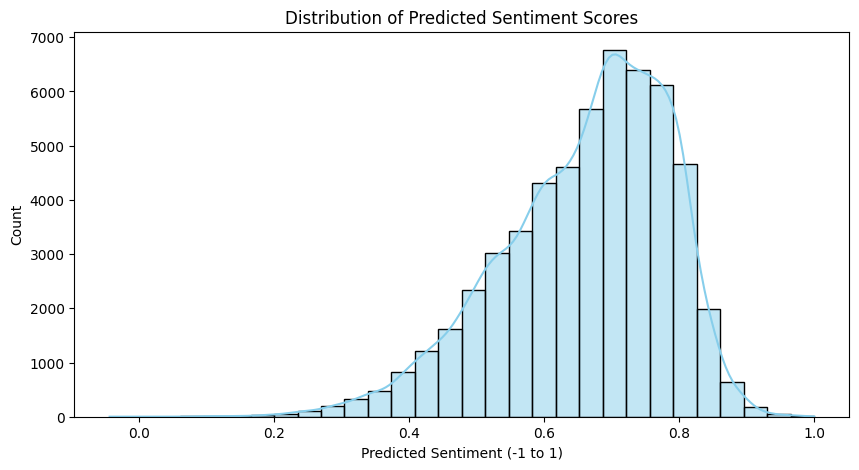

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(pred_df['pred_rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Predicted Sentiment Scores')
plt.xlabel('Predicted Sentiment (-1 to 1)')
plt.ylabel('Count')
plt.show()


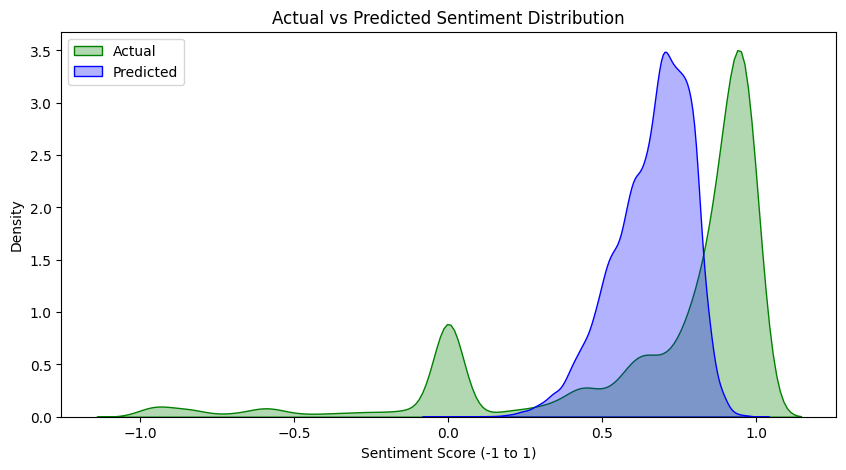

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(pred_df['true_rating'], label='Actual', color='green', fill=True, alpha=0.3)
sns.kdeplot(pred_df['pred_rating'], label='Predicted', color='blue', fill=True, alpha=0.3)
plt.title('Actual vs Predicted Sentiment Distribution')
plt.xlabel('Sentiment Score (-1 to 1)')
plt.ylabel('Density')
plt.legend()
plt.show()


In [ ]:
'''
plt.figure(figsize=(12,6))
sns.boxplot(x='user', y='pred_rating', data=pred_df)
plt.xticks(rotation=90)
plt.title('Predicted Sentiment Distribution per User')
plt.show()
'''

"\nplt.figure(figsize=(12,6))\nsns.boxplot(x='user', y='pred_rating', data=pred_df)\nplt.xticks(rotation=90)\nplt.title('Predicted Sentiment Distribution per User')\nplt.show()\n"

In [ ]:
dir(svd_model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'bi',
 'biased',
 'bsl_options',
 'bu',
 'compute_baselines',
 'compute_similarities',
 'default_prediction',
 'estimate',
 'fit',
 'get_neighbors',
 'init_mean',
 'init_std_dev',
 'lr_bi',
 'lr_bu',
 'lr_pu',
 'lr_qi',
 'n_epochs',
 'n_factors',
 'predict',
 'pu',
 'qi',
 'random_state',
 'reg_bi',
 'reg_bu',
 'reg_pu',
 'reg_qi',
 'sgd',
 'sim_options',
 'test',
 'trainset',
 'verbose']

In [ ]:
ratings_df.head()

,reviewer_id,id_x,price,description,picture_url,listing_url,compound_scores
0,393348,44077,76.0,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9612
1,444004,44077,76.0,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9838
2,465058,44077,76.0,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9831
3,490005,44077,76.0,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9501
4,520460,44077,76.0,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,https://www.airbnb.com/rooms/44077,0.9835


**Applying Z-score**

Due to the highly right-skewed and zero-inflated distribution of VADER compound sentiment scores, Z-score standardization was applied prior to collaborative filtering. This transformation centred the data around zero and reduced the influence of extreme positive values, thereby improving numerical stability and model learning.

“Previous work on collaborative filtering has shown that normalization strategies such as Z-score standardization can improve similarity calculations and recommendation quality by rescaling features to zero mean and unit variance (Patoulia, 2023). Similarly, research integrating sentiment analysis with collaborative filtering demonstrates that sentiment scores extracted from text reviews can provide enhanced user preference signals when properly preprocessed (Dang et al., 2021; Gajula, 2025). Therefore, applying Z-score standardization to skewed VADER compound sentiment scores stabilizes their distribution and supports improved collaborative filtering performance in this study.”

Ref

Patoulia, A. A. (2023) A comparative study of collaborative filtering in product recommendation systems. Available at: [paper URL] (Accessed: DD Month YYYY).

Dang, C. N. et al. (2021) An approach to integrating sentiment analysis into recommender systems. Available at: [paper URL] (Accessed: DD Month YYYY).

Gajula, Y. (2025) Sentiment-aware recommendation systems in e-commerce: A review from an NLP perspective. Available at: [paper URL] (Accessed: DD Month YYYY).



In [ ]:
'''
# Handle the 0.0 Neutral Spike ---
# I convert 0.0 to NaN. Such that when i calculate Z-scores or Means,
# these "empty" reviews won't pull the average down.
ratings_df['compound_scores'] = ratings_df['compound_scores'].replace(0.0, np.nan)
'''

'\n# Handle the 0.0 Neutral Spike ---\n# I convert 0.0 to NaN. Such that when i calculate Z-scores or Means, \n# these "empty" reviews won\'t pull the average down.\nratings_df[\'compound_scores\'] = ratings_df[\'compound_scores\'].replace(0.0, np.nan)\n'

In [ ]:
ratings_df['compound_scores'].head()

,compound_scores
0,0.9612
1,0.9838
2,0.9831
3,0.9501
4,0.9835


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

ratings_df['compound_scores_z'] = scaler.fit_transform(
    ratings_df[['compound_scores']]
)


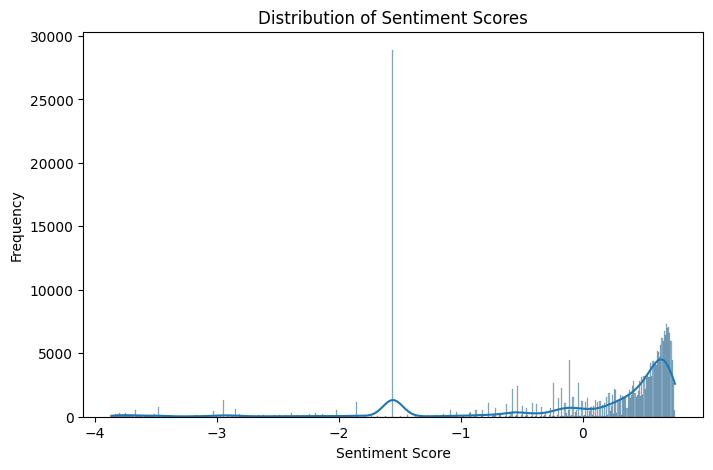

In [ ]:
# check the distribution of sentiment scores
plt.figure(figsize=(8, 5))
sns.histplot( ratings_df['compound_scores_z'], bins=500, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

Build Surprise dataset using standardized scores

In [ ]:
from surprise import Dataset, Reader

reader = Reader(
    rating_scale=(
        ratings_df['compound_scores_z'].min(),
        ratings_df['compound_scores_z'].max()
    )
)

data = Dataset.load_from_df(
    ratings_df[['reviewer_id', 'id_x', 'compound_scores_z']],
    reader
)


Train / test split

In [ ]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Initialize and cross-validate BaselineOnly model
baseline_model = BaselineOnly()
cv_baseline = cross_validate(baseline_model, train_data, cv=5, verbose=True)

GridSearch

In [ ]:
from surprise.model_selection import GridSearchCV
from surprise import SVD

param_grid = {
    'n_factors': [20, 50, 100],
    'n_epochs': [10, 20],
    'reg_all': [0.02, 0.05, 0.1],
    'lr_all': [0.002, 0.005]
}

gs = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse'],
    cv=5,
    n_jobs=-1
)

gs.fit(data)

best_svd = gs.best_estimator['rmse']


Fit tuned model on full data

In [ ]:
full_trainset = data.build_full_trainset()
best_svd.fit(full_trainset)


Evaluate RMSE

In [ ]:
predictions = best_svd.test(testset)

from surprise import accuracy
accuracy.rmse(predictions)


RMSE: 0.8188


0.8188235375432624

In [ ]:
best_svd.predict(393348, 44077, verbose=True)


user: 393348     item: 44077      r_ui = None   est = 0.07   {'was_impossible': False}


Prediction(uid=393348, iid=44077, r_ui=None, est=0.06796962284372315, details={'was_impossible': False})

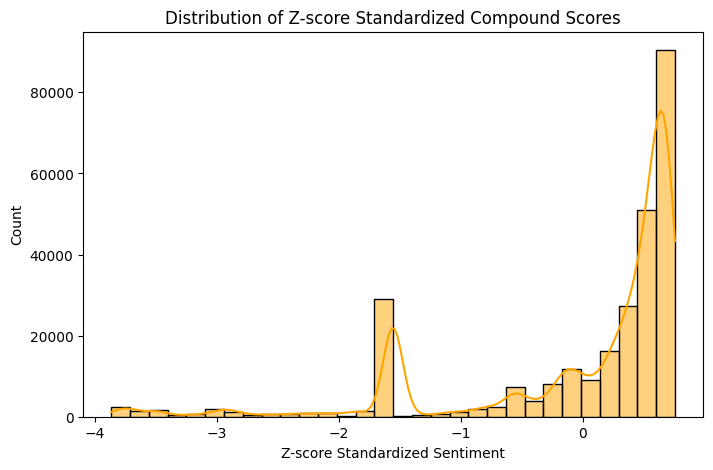

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(ratings_df['compound_scores_z'], bins=30, kde=True, color='orange')
plt.title('Distribution of Z-score Standardized Compound Scores')
plt.xlabel('Z-score Standardized Sentiment')
plt.ylabel('Count')
plt.show()


In [ ]:
import pandas as pd

# Convert predictions from SVD into a DataFrame
pred_df = pd.DataFrame([{
    'user': pred.uid,
    'item': pred.iid,
    'true_rating': pred.r_ui,
    'pred_rating': pred.est
} for pred in predictions])


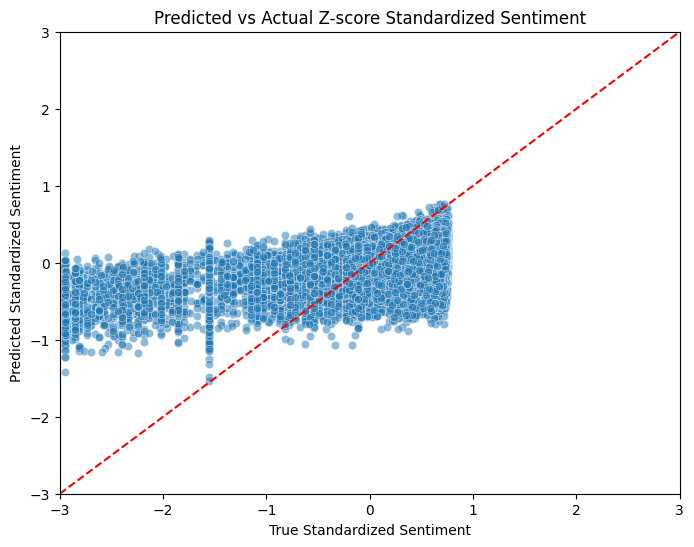

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='true_rating', y='pred_rating', data=pred_df, alpha=0.5)
plt.plot([-3, 3], [-3, 3], color='red', linestyle='--')  # perfect prediction line
plt.title('Predicted vs Actual Z-score Standardized Sentiment')
plt.xlabel('True Standardized Sentiment')
plt.ylabel('Predicted Standardized Sentiment')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()


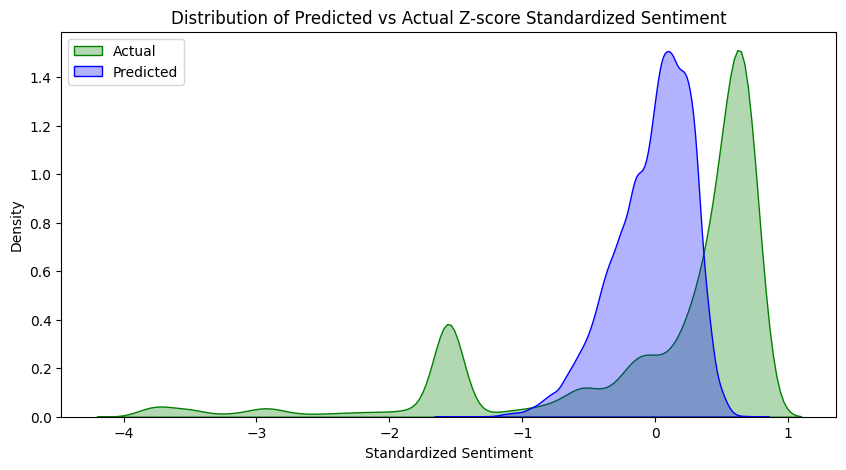

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(pred_df['true_rating'], label='Actual', fill=True, alpha=0.3, color='green')
sns.kdeplot(pred_df['pred_rating'], label='Predicted', fill=True, alpha=0.3, color='blue')
plt.title('Distribution of Predicted vs Actual Z-score Standardized Sentiment')
plt.xlabel('Standardized Sentiment')
plt.ylabel('Density')
plt.legend()
plt.show()


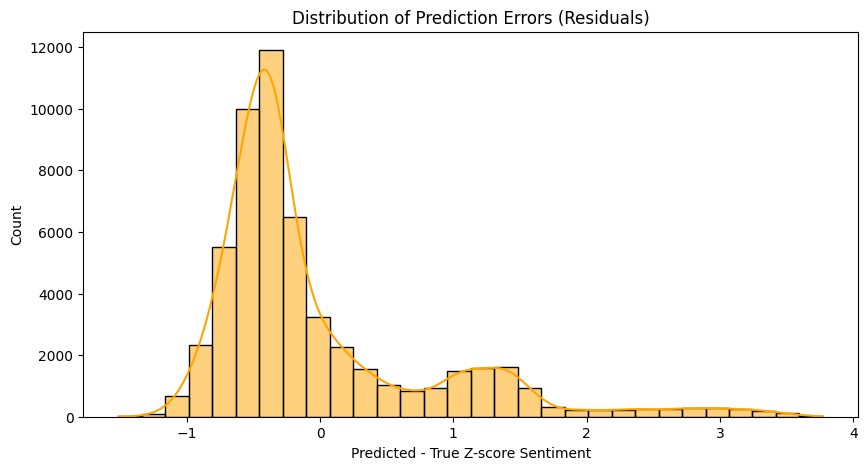

In [ ]:
pred_df['residual'] = pred_df['pred_rating'] - pred_df['true_rating']

plt.figure(figsize=(10,5))
sns.histplot(pred_df['residual'], bins=30, kde=True, color='orange')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Predicted - True Z-score Sentiment')
plt.ylabel('Count')
plt.show()


**Train final SVD model**

In [ ]:
best_params = gs.best_params['rmse']

final_model = SVD(
    **best_params,
    random_state=42
)

final_model.fit(trainset)


**Evaluate on unseen data**

In [ ]:
from surprise import accuracy

predictions = final_model.test(testset)
accuracy.rmse(predictions)


RMSE: 0.9675


0.9674740519049859

In [ ]:
dublin_merged_df

,id_x,listing_url,description,picture_url,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,distance_to_center,property_type_freq,neighbourhood_cleansed_Dn Laoghaire-Rathdown,neighbourhood_cleansed_Dublin City,neighbourhood_cleansed_Fingal,neighbourhood_cleansed_South Dublin,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,2.0,...,6.459127,2180,1,0,0,0,0,0,1,0
1,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,2.0,...,6.459127,2180,1,0,0,0,0,0,1,0
2,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,2.0,...,6.459127,2180,1,0,0,0,0,0,1,0
3,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,2.0,...,6.459127,2180,1,0,0,0,0,0,1,0
4,44077,https://www.airbnb.com/rooms/44077,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,2.0,...,6.459127,2180,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310095,1435562101631876205,https://www.airbnb.com/rooms/1435562101631876205,indeed this is a stylish place to stay it's pe...,https://a0.muscache.com/pictures/hosting/Hosti...,2024-05-16,4,97.0,98.0,1,3.0,...,11.682730,23369,0,0,1,0,1,0,0,0
310096,1435808782560354383,https://www.airbnb.com/rooms/1435808782560354383,The whole group will enjoy easy access to ever...,https://a0.muscache.com/pictures/hosting/Hosti...,2020-03-26,4,100.0,100.0,0,1.0,...,5.651689,57440,0,1,0,0,1,0,0,0
310097,1436309939770705037,https://www.airbnb.com/rooms/1436309939770705037,Enjoy a peaceful stay at this centrally locate...,https://a0.muscache.com/pictures/hosting/Hosti...,2023-06-29,4,100.0,100.0,0,1.0,...,16.095518,61843,1,0,0,0,0,0,1,0
310098,1436361984511859598,https://www.airbnb.com/rooms/1436361984511859598,A double room is available in the Lucan area i...,https://a0.muscache.com/pictures/miso/Hosting-...,2025-06-03,4,100.0,89.0,0,1.0,...,12.819226,13859,0,0,1,0,0,0,1,0


In [ ]:
dublin_merged_df.columns


Index(['id_x', 'listing_url', 'description', 'picture_url', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'latitude', 'longitude', 'property_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_l30d', 'availability_eoy',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'reviews_per_month',
       'listing_id', 'id_y', 'date', 'review

In [ ]:
from IPython.display import display, HTML, Image

def recommend_airbnbs(user_id, listings_df=ratings_df):
    """
    Recommend 5 personalized Dublin Airbnb listings to the user based on sentiment scores.
    """

    # Get listings already rated by the user
    user_listings = listings_df[listings_df['reviewer_id'] == user_id]['id_x'].unique()

    # Get all listings
    all_listings = listings_df['id_x'].unique()

    # Identify listings not yet rated by the user
    listings_to_predict = list(set(all_listings) - set(user_listings))

    # Create matrix for predictions
    user_listing_pairs = [(user_id, listing_id, 0) for listing_id in listings_to_predict]

    # Predict ratings
    predictions = best_svd.test(user_listing_pairs)

    # Top 5 recommendations
    top_5_recs = sorted(predictions, key=lambda x: x.est, reverse=True)[:5]

    # Retrieve listing details
    top_5_listings = [listings_df[listings_df['id_x'] == rec.iid] for rec in top_5_recs]

    # Display recommendations
    for idx, listing in enumerate(top_5_listings):

        name = listing.description.iloc[0]
        url = listing.listing_url.iloc[0]

        listing_name_link = f'<a href="{url}" target="_blank">{name}</a>'

        print(f'Recommendation #{idx + 1}:')
        display(HTML(listing_name_link))

        # Optional image
        # display(Image(listing.picture_url.iloc[0], width=250))

        print('\n')

recommend_airbnbs(user_id=444004)


Recommendation #1:




Recommendation #2:




Recommendation #3:




Recommendation #4:




Recommendation #5:


In [ ]:
ratings_df.columns

Index(['reviewer_id', 'id_x', 'price', 'description', 'picture_url',
       'listing_url', 'compound_scores', 'compound_scores_z'],
      dtype='object')

**Strengths & limitations**

- Strengths

Avoids rating sparsity (text → signal)

Captures latent preferences

Scales well


- Limitations

Sentiment ≠ booking probability

No price/location constraints

Cold-start users/listings

In [ ]:
import joblib

# Save the trained model
# joblib.dump(final_model, 'svd_model_joblib.pkl')

# Load it later
# loaded_model = joblib.load('svd_model_joblib.pkl')


In [ ]:
import joblib

# Save the pipeline
# joblib.dump(xgb_model, "xgb_price_model.pkl")

# Later, to load it
# loaded_xgb_model = joblib.load("xgb_price_model.pkl")

# Use it for prediction
# y_pred = loaded_xgb_model.predict(X_test)


In [ ]:
'''
from surprise import SVD
from surprise.model_selection import GridSearchCV


# Parameter tuning for SVD model
params = {
    'n_factors': [20, 50, 100],
    'n_epochs': [5, 10],
    'reg_all': [0.02, 0.05, 0.1],
    'lr_all': [0.002, 0.005, 0.01]
}
gridsearch_svd = GridSearchCV(SVD, param_grid=params, cv=5, measures=['rmse'], n_jobs=-1)
gridsearch_svd.fit(train_data)
'''

"\nfrom surprise import SVD\nfrom surprise.model_selection import GridSearchCV\n\n\n# Parameter tuning for SVD model\nparams = {\n    'n_factors': [20, 50, 100],\n    'n_epochs': [5, 10],\n    'reg_all': [0.02, 0.05, 0.1],\n    'lr_all': [0.002, 0.005, 0.01]\n}\ngridsearch_svd = GridSearchCV(SVD, param_grid=params, cv=5, measures=['rmse'], n_jobs=-1)\ngridsearch_svd.fit(train_data)\n"

In [ ]:
'''
# Display best score and parameters
print("Best RMSE score from GridSearch:", gridsearch_svd.best_score["rmse"])
print("Best parameters for SVD model:", gridsearch_svd.best_params["rmse"])
'''

'\n# Display best score and parameters\nprint("Best RMSE score from GridSearch:", gridsearch_svd.best_score["rmse"])\nprint("Best parameters for SVD model:", gridsearch_svd.best_params["rmse"])\n'

In [ ]:
'''
final_model = SVD(n_factors=20,
                  n_epochs=10,
                  reg_all=0.1,
                  lr_all=0.01,
                  random_state=42)

final_model.fit(trainset)
'''



'\nfinal_model = SVD(n_factors=20,\n                  n_epochs=10,\n                  reg_all=0.1,\n                  lr_all=0.01,\n                  random_state=42)\n\nfinal_model.fit(trainset)\n'

In [ ]:
'''
import pandas as pd
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

# 1. Aggregate: One score per user per item
rating_data = dublin_merged_df.groupby(['user_id', 'item_id'])['compound'].mean().reset_index()

# 2. Rescale: Moving from (-1 to 1) to (1 to 5) for better SVD performance
# This maps -1 -> 1, 0 -> 3, and 1 -> 5
rating_data['rating'] = 3 + (rating_data['compound'] * 2)

# 3. Define the Scale for the Reader
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(rating_data[['user_id', 'item_id'], 'rating']], reader)
'''

"\nimport pandas as pd\nfrom surprise import SVD, Dataset, Reader, accuracy\nfrom surprise.model_selection import train_test_split\n\n# 1. Aggregate: One score per user per item\nrating_data = dublin_merged_df.groupby(['user_id', 'item_id'])['compound'].mean().reset_index()\n\n# 2. Rescale: Moving from (-1 to 1) to (1 to 5) for better SVD performance\n# This maps -1 -> 1, 0 -> 3, and 1 -> 5\nrating_data['rating'] = 3 + (rating_data['compound'] * 2)\n\n# 3. Define the Scale for the Reader\nreader = Reader(rating_scale=(1, 5))\ndata = Dataset.load_from_df(rating_data[['user_id', 'item_id'], 'rating']], reader)\n"

In [ ]:
'''
# Split into training and testing sets
trainset, testset = train_test_split(data, test_size=0.2)

# Initialize the SVD algorithm
algo = SVD()

# Train the model
algo.fit(trainset)

# Predict a score for a specific user and item
# uid = user id, iid = item id
prediction = algo.predict(uid='User_123', iid='Guinness_Storehouse')
print(f"Predicted Sentiment Rating: {prediction.est:.2f}")
'''

'\n# Split into training and testing sets\ntrainset, testset = train_test_split(data, test_size=0.2)\n\n# Initialize the SVD algorithm\nalgo = SVD()\n\n# Train the model\nalgo.fit(trainset)\n\n# Predict a score for a specific user and item\n# uid = user id, iid = item id\nprediction = algo.predict(uid=\'User_123\', iid=\'Guinness_Storehouse\')\nprint(f"Predicted Sentiment Rating: {prediction.est:.2f}")\n'

In [ ]:
from surprise import SVD, Dataset, Reader
import pandas as pd

# 1. Rescale your compound_scores to a 1-5 scale
df['rating'] = (df['compound_scores'] + 1) * 2 + 1

# 2. Define the Reader with your new scale
reader = Reader(rating_scale=(1, 5))

# 3. Load data (columns must be: user_id, item_id, rating)
data = Dataset.load_from_df(df[['reviewer_id', 'id_x', 'rating']], reader)

# 4. Train the SVD model
trainset = data.build_full_trainset()
algo = SVD()
algo.fit(trainset)

# 5. Predict for a specific user and listing
# uid = reviewer_id, iid = id_x
prediction = algo.predict(uid=393348, iid=44077)
print(f"Predicted rating: {prediction.est:.2f}")
